<center>
<img src="https://drive.google.com/uc?id=1f1gGVI-rxcHjA90WEGNvvtSXF1pAxQwg" alt="Fasilkom UI" width="240"/>

# Indonesian Food Ingredient & Nutrition Analyzer

### CNN + Web Mining + Vision-Language Model Pipeline

**Kaggle-Ready Portfolio Notebook** • Computer Vision • Weak Supervision • Vision-Language Models
</center>

---

This notebook presents an end-to-end food image analysis project focused on Indonesian dishes. The project starts with a conventional CNN baseline, then evaluates how well it transfers to Indonesian food images, builds weak labels from web/text mining, and finally compares the CNN with a Vision-Language Model (VLM) that produces structured ingredient and nutrition estimates.

The notebook is intentionally written as a **portfolio project**, not just a question-answering demo. The VLM is used as a structured analysis component inside a larger machine learning pipeline.


## Project Card

| Item | Description |
|---|---|
| **Project Name** | Indonesian Food Ingredient & Nutrition Analyzer |
| **Problem** | Predict and analyze food ingredients from images, especially Indonesian dishes where labels and visual appearance differ from common global recipe datasets. |
| **Main Input** | Food image. |
| **Main Outputs** | CNN ingredient predictions, web-mined weak labels, VLM structured ingredient reports, estimated nutrition values, and model comparison metrics. |
| **Core Methods** | ResNet18 multi-label classification, web/text mining, weak supervision, prompt engineering, structured JSON parsing, VLM inference, and optional LoRA smoke test. |
| **Baseline Model** | ResNet18 trained as a multi-label ingredient classifier. |
| **Multimodal Model** | Qwen2-VL used as a structured food analyzer. |
| **Evaluation Focus** | Transfer performance, label-space mismatch, weak-label evaluation, hallucination analysis, and CNN-vs-VLM comparison. |
| **Best Runtime Target** | Kaggle Notebook with GPU accelerator enabled. |

This project is useful as a portfolio piece because it combines practical ML engineering with realistic limitations: noisy labels, domain shift, unavailable ground truth, fixed-vocabulary classifiers, and VLM hallucination risk.


## Executive Summary

This project builds a **multimodal food understanding pipeline** through four connected phases:

| Phase | Component | Purpose | Main Finding |
|---|---|---|---|
| **1** | CNN ingredient classifier | Train a baseline multi-label image classifier on a global food recipe dataset. | The CNN can learn common ingredient patterns but is constrained by a fixed vocabulary. |
| **2** | Zero-shot Indonesian transfer | Test the CNN on Indonesian food images without retraining on Indonesian labels. | The model struggles because Indonesian foods introduce both visual domain shift and ingredient vocabulary mismatch. |
| **3** | Web/text mining | Generate weak ingredient labels from recipe snippets and bilingual ingredient dictionaries. | Web-mined labels improve evaluation coverage but introduce noise. |
| **4** | Vision-Language Model | Use a VLM as a structured food analyzer for ingredient and nutrition estimation. | The VLM produces more semantically relevant outputs than the CNN, but still needs hallucination checks. |

The key lesson is that food image understanding is not only about model accuracy. For Indonesian dishes, **data coverage, label vocabulary, cultural ingredient representation, prompt design, and evaluation quality** are equally important.


## Reproducibility and Runtime Notes

This version is prepared for **Kaggle Notebook execution**. It can still be opened locally, but the heavier parts of the project, especially the VLM and LoRA sections, are designed for a GPU-backed environment.

### Recommended Kaggle settings

Before running the notebook on Kaggle:

1. Upload/import this notebook to Kaggle.
2. Open **Notebook Settings**.
3. Set **Accelerator** to **GPU**.
4. Enable **Internet** if you want the notebook to download packages, Hugging Face models, or Kaggle datasets automatically.
5. Add the required datasets as Kaggle inputs if you prefer not to download them at runtime.

### Why GPU matters here

The CNN sections can technically run on CPU, but they will be slower. The VLM section is much heavier because it loads and runs a multimodal transformer. For practical runtime, Phase 4 should be run with CUDA GPU support.

The notebook automatically detects the environment and prints:

- whether it is running on Kaggle,
- which device PyTorch is using,
- whether CUDA is available,
- the GPU name when available,
- DataLoader settings such as `num_workers` and `pin_memory`.

If you run locally and see a warning such as `pin_memory argument is set as true but no accelerator is found`, it means PyTorch only detected CPU. This notebook avoids that warning by enabling pinned memory only when CUDA is available.

### Required datasets

The project uses these public Kaggle datasets:

| Dataset | Kaggle Slug | Used In |
|---|---|---|
| Food Ingredients and Recipes with Images | `pes12017000148/food-ingredients-and-recipe-dataset-with-images` | Phase 1 training |
| Indonesian Food Classification Dataset | `rizkyyk/dataset-food-classification` | Phase 2–4 evaluation |
| Food Recipes Dataset | `albertnathaniel12/food-recipes-dataset` | Optional Phase 3 recipe corpus |

The notebook can either find datasets from `/kaggle/input` or download them with `kagglehub`.


---

# Phase 1 — CNN Multi-Label Ingredient Classifier

This phase builds the project baseline: a CNN that predicts multiple ingredients from one food image.

## Why multi-label classification?

Food images usually contain more than one ingredient. A single-label classifier would force the model to pick one class, such as `pizza` or `burger`, but this project needs ingredient-level outputs such as `cheese`, `tomato`, `chicken`, `egg`, and `rice`. Therefore, the model is trained as a **multi-label classifier**:

- each ingredient has its own output neuron,
- each output is treated independently with sigmoid activation,
- the model can predict multiple ingredients for a single image.

## Dataset

The baseline uses the Kaggle **Food Ingredients and Recipes Dataset with Images**. The dataset includes recipe metadata, image names, and ingredient strings. Because the ingredient strings contain quantities and cooking descriptors, they must be cleaned before they can be used as labels.

## Main tasks in this phase

1. Download or locate the dataset.
2. Parse and clean ingredient strings.
3. Build a top-N ingredient vocabulary.
4. Convert each recipe into a multi-label target vector.
5. Train a ResNet18-based classifier.
6. Evaluate validation precision, recall, and F1.
7. Tune the prediction threshold.
8. Analyze false positives and false negatives.


In [1]:
# Runtime dependency setup.
# Kaggle/local dataset resolution already includes most data science packages, but these extra packages are needed
# for dataset access, web/text mining, VLM inference, and optional LoRA adaptation.

import os
import sys
import subprocess
import importlib.util

IS_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None or os.path.exists("/kaggle/input")

PACKAGES_TO_INSTALL = [
    "kagglehub",
    "torchmetrics",
    "ddgs",
    "transformers>=4.45",
    "accelerate",
    "qwen-vl-utils",
    "peft",
    "safetensors",
]

def package_is_available(import_name):
    return importlib.util.find_spec(import_name) is not None

missing_packages = []
for package_name in PACKAGES_TO_INSTALL:
    import_name = package_name.split(">=")[0].replace("-", "_")
    if import_name == "qwen_vl_utils":
        import_name = "qwen_vl_utils"
    if not package_is_available(import_name):
        missing_packages.append(package_name)

if missing_packages:
    print("Installing missing packages:", missing_packages)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])
else:
    print("All required extra packages are already available.")

print("Running on Kaggle:", IS_KAGGLE)


All required extra packages are already available.
Running on Kaggle: True


In [2]:
import os
import re
import ast
import json
import random
import math
import time
import gc
import platform
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms, models

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

import kagglehub


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

IS_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None or Path("/kaggle/input").exists()

PIN_MEMORY = DEVICE.type == "cuda"
NUM_WORKERS = 2 if (IS_KAGGLE or os.name != "nt") else 0

print("Environment")
print("-----------")
print("Kaggle environment:", IS_KAGGLE)
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("CUDA available:", torch.cuda.is_available())
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version used by PyTorch:", torch.version.cuda)
else:
    print("CUDA available:", False)
    print("No CUDA GPU detected. CNN training will be slower and Phase 4 VLM inference is not recommended locally.")

print("DataLoader num_workers:", NUM_WORKERS)
print("DataLoader pin_memory:", PIN_MEMORY)


Environment
-----------
Kaggle environment: True
Python: 3.12.13
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cu128
Device: cuda
CUDA available: True
GPU: Tesla T4
CUDA version used by PyTorch: 12.8
DataLoader num_workers: 2
DataLoader pin_memory: True


## 1.1 Dataset Access

This section locates the Phase 1 recipe-image dataset. The notebook supports three execution styles:

1. **Kaggle input mode**  
   Add the dataset to the Kaggle notebook through **Add Input**. The notebook will search `/kaggle/input` for a matching folder.

2. **Runtime download mode**  
   If the dataset is not found locally, the notebook attempts to download it using `kagglehub`.

3. **Local mode**  
   If running on your own computer, place the dataset under:

```text
data/raw/food-ingredients-and-recipes/
```

A helper function is used so the same notebook can run on Kaggle and local environments with minimal edits.


In [4]:
def print_directory_preview(base_dir, max_depth=2, max_files=5):
    base_dir = Path(base_dir)

    if not base_dir.exists():
        print("Directory does not exist:", base_dir)
        return

    print("Dataset folder:", base_dir)

    for root, dirs, files in os.walk(base_dir):
        root_path = Path(root)

        try:
            level = len(root_path.relative_to(base_dir).parts)
        except ValueError:
            level = 0

        if level >= max_depth:
            continue

        print("  " * level + root_path.name + "/")

        for file_name in files[:max_files]:
            print("  " * (level + 1) + file_name)

        if len(files) > max_files:
            print("  " * (level + 1) + f"... (+{len(files) - max_files} more)")


def find_kaggle_input_by_hints(hints):
    input_root = Path("/kaggle/input")

    if not input_root.exists():
        return None

    normalized_hints = [h.lower() for h in hints]

    for candidate in input_root.iterdir():
        if not candidate.is_dir():
            continue

        candidate_name = candidate.name.lower()
        if any(hint in candidate_name for hint in normalized_hints):
            return candidate

    return None


def resolve_dataset_dir(kaggle_slug, local_dir, kaggle_hints):
    local_dir = Path(local_dir)

    kaggle_input_dir = find_kaggle_input_by_hints(kaggle_hints)
    if kaggle_input_dir is not None:
        print("Using Kaggle input dataset:", kaggle_input_dir)
        return kaggle_input_dir

    if local_dir.exists():
        print("Using local dataset:", local_dir)
        return local_dir

    print("Dataset not found locally. Downloading with kagglehub:", kaggle_slug)
    return Path(kagglehub.dataset_download(kaggle_slug))


RECIPE_DATASET_DIR = resolve_dataset_dir(
    kaggle_slug="pes12017000148/food-ingredients-and-recipe-dataset-with-images",
    local_dir="data/raw/food-ingredients-and-recipes",
    kaggle_hints=[
        "food-ingredients-and-recipe",
        "food-ingredients",
        "recipe-dataset-with-images",
    ],
)

print_directory_preview(RECIPE_DATASET_DIR)


Dataset not found locally. Downloading with kagglehub: pes12017000148/food-ingredients-and-recipe-dataset-with-images
Dataset folder: /kaggle/input/datasets/pes12017000148/food-ingredients-and-recipe-dataset-with-images
food-ingredients-and-recipe-dataset-with-images/
  Food Ingredients and Recipe Dataset with Image Name Mapping.csv
  Food Images/


In [5]:
csv_files = list(Path(RECIPE_DATASET_DIR).rglob("*.csv"))
image_dirs = [
    p for p in Path(RECIPE_DATASET_DIR).rglob("*")
    if p.is_dir() and any(p.glob("*.jpg"))
]

print("CSV files found:", csv_files)
print("Image directories found:", image_dirs[:3])

if not csv_files:
    raise FileNotFoundError(
        "No CSV file was found in the recipe dataset folder. "
        "Check that the dataset was added correctly to Kaggle or placed under data/raw."
    )

if not image_dirs:
    raise FileNotFoundError(
        "No image directory with .jpg files was found. "
        "Check the extracted dataset structure."
    )

RECIPE_CSV = csv_files[0]
RECIPE_IMG_DIR = image_dirs[0]

print("Using CSV:", RECIPE_CSV)
print("Using image directory:", RECIPE_IMG_DIR)


CSV files found: [PosixPath('/kaggle/input/datasets/pes12017000148/food-ingredients-and-recipe-dataset-with-images/Food Ingredients and Recipe Dataset with Image Name Mapping.csv')]
Image directories found: [PosixPath('/kaggle/input/datasets/pes12017000148/food-ingredients-and-recipe-dataset-with-images/Food Images/Food Images')]
Using CSV: /kaggle/input/datasets/pes12017000148/food-ingredients-and-recipe-dataset-with-images/Food Ingredients and Recipe Dataset with Image Name Mapping.csv
Using image directory: /kaggle/input/datasets/pes12017000148/food-ingredients-and-recipe-dataset-with-images/Food Images/Food Images


## 1.2 CSV Exploration

This section inspects the recipe metadata before label cleaning. The most important columns are usually:

- recipe title or name,
- image filename,
- raw ingredient list,
- optional recipe instructions or metadata.

The raw ingredient field is not immediately suitable for model training because it often contains quantities, units, descriptors, and preparation phrases. For example, an ingredient such as `"2 tablespoons finely chopped onion"` should contribute a label like `onion`, not `tablespoons` or `finely`.

The output of this section helps verify that the dataset structure has been loaded correctly before the cleaning pipeline is applied.


In [6]:
df_recipes = pd.read_csv(RECIPE_CSV)
print('Shape:', df_recipes.shape)
print('Columns:', df_recipes.columns.tolist())
df_recipes.head(3)

Shape: (13501, 6)
Columns: ['Unnamed: 0', 'Title', 'Ingredients', 'Instructions', 'Image_Name', 'Cleaned_Ingredients']


,Unnamed: 0,Title,Ingredients,Instructions,Image_Name,Cleaned_Ingredients
0,0,Miso-Butter Roast Chicken With Acorn Squash Pa...,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher...","Pat chicken dry with paper towels, season all ...",miso-butter-roast-chicken-acorn-squash-panzanella,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher..."
1,1,Crispy Salt and Pepper Potatoes,"['2 large egg whites', '1 pound new potatoes (...",Preheat oven to 400°F and line a rimmed baking...,crispy-salt-and-pepper-potatoes-dan-kluger,"['2 large egg whites', '1 pound new potatoes (..."
2,2,Thanksgiving Mac and Cheese,"['1 cup evaporated milk', '1 cup whole milk', ...",Place a rack in middle of oven; preheat to 400...,thanksgiving-mac-and-cheese-erick-williams,"['1 cup evaporated milk', '1 cup whole milk', ..."


The `Ingredients` column stores ingredient lists as strings that look like Python lists, for example:

```text
"['1 cup rice', '2 eggs', '1 tbsp soy sauce']"
```

The notebook uses `ast.literal_eval` to safely convert those strings into Python lists. After parsing, each ingredient is normalized by removing quantity words, measurement units, and preparation descriptors. This is important because the model should learn meaningful ingredient concepts, not recipe-writing artifacts.


In [7]:
def parse_ingredients_field(s):
    """Parsing string list-of-strings ke list Python."""
    if pd.isna(s) or not isinstance(s, str):
        return []
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(x) for x in v]
    except Exception:
        pass
    return []

# Stopword: kata yang biasa muncul di Ingredients tapi bukan ingredient sebenarnya
STOPWORDS = {
    'cup', 'cups', 'tablespoon', 'tablespoons', 'tbsp', 'teaspoon', 'teaspoons', 'tsp',
    'pound', 'pounds', 'lb', 'lbs', 'ounce', 'ounces', 'oz', 'gram', 'grams', 'g', 'kg',
    'ml', 'liter', 'liters', 'l', 'pinch', 'dash', 'slice', 'slices', 'piece', 'pieces',
    'large', 'small', 'medium', 'fresh', 'dried', 'frozen', 'canned', 'cooked', 'raw',
    'chopped', 'sliced', 'minced', 'diced', 'grated', 'ground', 'whole', 'halved',
    'to', 'taste', 'and', 'or', 'the', 'a', 'an', 'of', 'in', 'with', 'for', 'about',
    'plus', 'optional', 'cut', 'cubed', 'peeled', 'seeded', 'finely', 'roughly',
    'inch', 'inches', 'cm', 'mm', 'serving', 'servings', 'package', 'packages', 'pkg',
    'softened', 'melted', 'beaten', 'divided', 'room', 'temperature', 'cold', 'warm', 'hot',
    'as', 'needed', 'extra', 'virgin', 'unsalted', 'salted', 'sweet', 'sour',
    'leaves', 'leaf', 'stalks', 'stalk', 'cloves', 'clove', 'sprigs', 'sprig',
    'rinsed', 'drained', 'thawed', 'trimmed', 'cleaned', 'wiped', 'pitted', 'cored',
    'thinly', 'thickly', 'very', 'about', 'approximately', 'such', 'as',
}

TOKEN_RE = re.compile(r"[a-zA-Z]+")
NUM_RE = re.compile(r"\d+(\.\d+)?(/\d+)?")

def clean_ingredient_string(s):
    """Bersihkan satu string ingredient → list lemma sederhana (lowercase, tanpa angka/satuan/stopword)."""
    s = s.lower()
    s = NUM_RE.sub(' ', s)
    s = re.sub(r"\([^)]*\)", ' ', s)  # hapus isi dalam kurung
    tokens = TOKEN_RE.findall(s)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return tokens

# Test
sample_raw = df_recipes['Ingredients'].iloc[0]
sample_list = parse_ingredients_field(sample_raw)
print('Raw ingredient strings:')
for s in sample_list[:5]:
    print('  ', s)
print()
print('Cleaned tokens:')
for s in sample_list[:5]:
    print('  ', s, '→', clean_ingredient_string(s))

Raw ingredient strings:
   1 (3½–4-lb.) whole chicken
   2¾ tsp. kosher salt, divided, plus more
   2 small acorn squash (about 3 lb. total)
   2 Tbsp. finely chopped sage
   1 Tbsp. finely chopped rosemary

Cleaned tokens:
   1 (3½–4-lb.) whole chicken → ['chicken']
   2¾ tsp. kosher salt, divided, plus more → ['kosher', 'salt', 'more']
   2 small acorn squash (about 3 lb. total) → ['acorn', 'squash']
   2 Tbsp. finely chopped sage → ['sage']
   1 Tbsp. finely chopped rosemary → ['rosemary']


## 1.3 Ingredient Vocabulary Construction

The baseline CNN cannot predict unlimited ingredients. It needs a fixed output dimension, so this section builds a vocabulary from the most frequent cleaned ingredient tokens.

A top-N vocabulary is a practical compromise:

- it keeps the output layer small enough for efficient training,
- it focuses on ingredients with enough examples,
- it reduces extreme label sparsity,
- but it also creates a limitation because rare or culturally specific ingredients may be excluded.

This trade-off becomes important later when the model is evaluated on Indonesian food images.


In [8]:
# Parse semua recipes (akan dipakai untuk vocab + Dataset class)
df_recipes['ingredients_parsed'] = df_recipes['Ingredients'].apply(parse_ingredients_field)
df_recipes['ingredients_tokens'] = df_recipes['ingredients_parsed'].apply(
    lambda lst: list({tok for s in lst for tok in clean_ingredient_string(s)})
)

# Buang baris tanpa Image_Name atau tanpa ingredient
df_recipes = df_recipes[df_recipes['Image_Name'].notna() & df_recipes['Image_Name'].astype(str).str.len().gt(0)].copy()
df_recipes = df_recipes[df_recipes['ingredients_tokens'].map(len) > 0].copy()
print('Recipes setelah filter:', len(df_recipes))

# Hitung frekuensi token
token_counter = Counter()
for toks in df_recipes['ingredients_tokens']:
    token_counter.update(toks)

print('Unique tokens:', len(token_counter))
print('Top 20:', token_counter.most_common(20))


Recipes setelah filter: 13488
Unique tokens: 5910
Top 20: [('salt', 8999), ('oil', 7380), ('pepper', 5205), ('olive', 4958), ('sugar', 4806), ('kosher', 4760), ('butter', 4350), ('garlic', 4189), ('into', 4073), ('black', 3791), ('juice', 3781), ('freshly', 3445), ('lemon', 3076), ('red', 2996), ('flour', 2845), ('white', 2643), ('all', 2421), ('cream', 2403), ('onion', 2363), ('vegetable', 2351)]


Vocabulary size: 100
Sample: ['all', 'at', 'baking', 'basil', 'bay', 'beans', 'black', 'boneless', 'bread', 'broth', 'brown', 'butter', 'can', 'celery', 'cheese', 'chicken', 'chile', 'chilled', 'chocolate', 'cilantro']


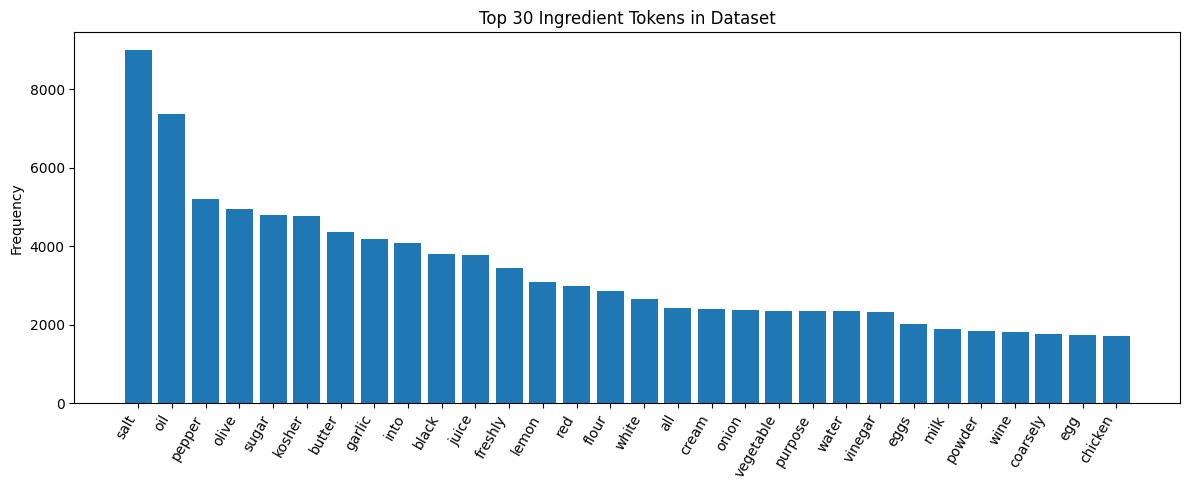

In [9]:
VOCAB_SIZE = 100
ALL_INGREDIENTS = [tok for tok, _ in token_counter.most_common(VOCAB_SIZE)]
ALL_INGREDIENTS = sorted(ALL_INGREDIENTS)  # urut alfabet untuk konsistensi

ingredient_to_idx = {ing: i for i, ing in enumerate(ALL_INGREDIENTS)}
idx_to_ingredient = {i: ing for ing, i in ingredient_to_idx.items()}

num_ingredients = len(ALL_INGREDIENTS)
print(f'Vocabulary size: {num_ingredients}')
print(f'Sample: {ALL_INGREDIENTS[:20]}')

# Plot top-30
top30 = token_counter.most_common(30)
plt.figure(figsize=(12, 5))
plt.bar([t for t, _ in top30], [c for _, c in top30])
plt.xticks(rotation=60, ha='right')
plt.ylabel('Frequency')
plt.title('Top 30 Ingredient Tokens in Dataset')
plt.tight_layout(); plt.show()


## 1.4 Dataset Class and Image Transforms

`RecipeImageDataset` converts the cleaned dataframe into PyTorch training samples.

Each sample returns:

```text
(image_tensor, multilabel_vector, title)
```

The `multilabel_vector` has one position per ingredient in the vocabulary. A value of `1` means the ingredient appears in the recipe, while `0` means it does not.

The training transform includes mild augmentation to improve generalization. The validation transform is deterministic so validation metrics are easier to compare across runs.


In [10]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


In [11]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp'}

def resolve_image_path(image_name, base_dir=RECIPE_IMG_DIR):
    base = Path(base_dir)
    # Coba beberapa ekstensi umum
    for ext in ['.jpg', '.jpeg', '.png']:
        p = base / f'{image_name}{ext}'
        if p.exists():
            return p
    # Mungkin Image_Name sudah punya ekstensi
    p = base / image_name
    if p.exists():
        return p
    return None

# Filter recipes yang gambarnya ada
df_recipes['image_path'] = df_recipes['Image_Name'].apply(resolve_image_path)
df_recipes_valid = df_recipes[df_recipes['image_path'].notna()].reset_index(drop=True)
print(f'Recipes dengan gambar valid: {len(df_recipes_valid)} / {len(df_recipes)}')


Recipes dengan gambar valid: 13458 / 13488


In [12]:
class RecipeImageDataset(Dataset):
    def __init__(self, df, ingredient_to_idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.ingredient_to_idx = ingredient_to_idx
        self.transform = transform
        self.num_ingredients = len(ingredient_to_idx)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        # Build multi-label vector
        labels = torch.zeros(self.num_ingredients, dtype=torch.float32)
        for tok in row['ingredients_tokens']:
            if tok in self.ingredient_to_idx:
                labels[self.ingredient_to_idx[tok]] = 1.0
        return img, labels, row.get('Title', '')

# Train/val split
from sklearn.model_selection import train_test_split
df_train, df_val = train_test_split(df_recipes_valid, test_size=0.1, random_state=SEED, shuffle=True)
print(f'Train: {len(df_train)}, Val: {len(df_val)}')

train_ds = RecipeImageDataset(df_train, ingredient_to_idx, train_transform)
val_ds   = RecipeImageDataset(df_val,   ingredient_to_idx, test_transform)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)


Train: 12112, Val: 1346


## 1.5 Sample Visualization

Before training, the notebook visualizes several image-label pairs. This is a simple but important data validation step.

The goal is to catch issues such as:

- broken image paths,
- incorrect image-to-recipe matching,
- labels that look too noisy,
- unexpected image formats,
- preprocessing problems.

If the labels and images look unreasonable at this stage, training metrics will be difficult to interpret later.


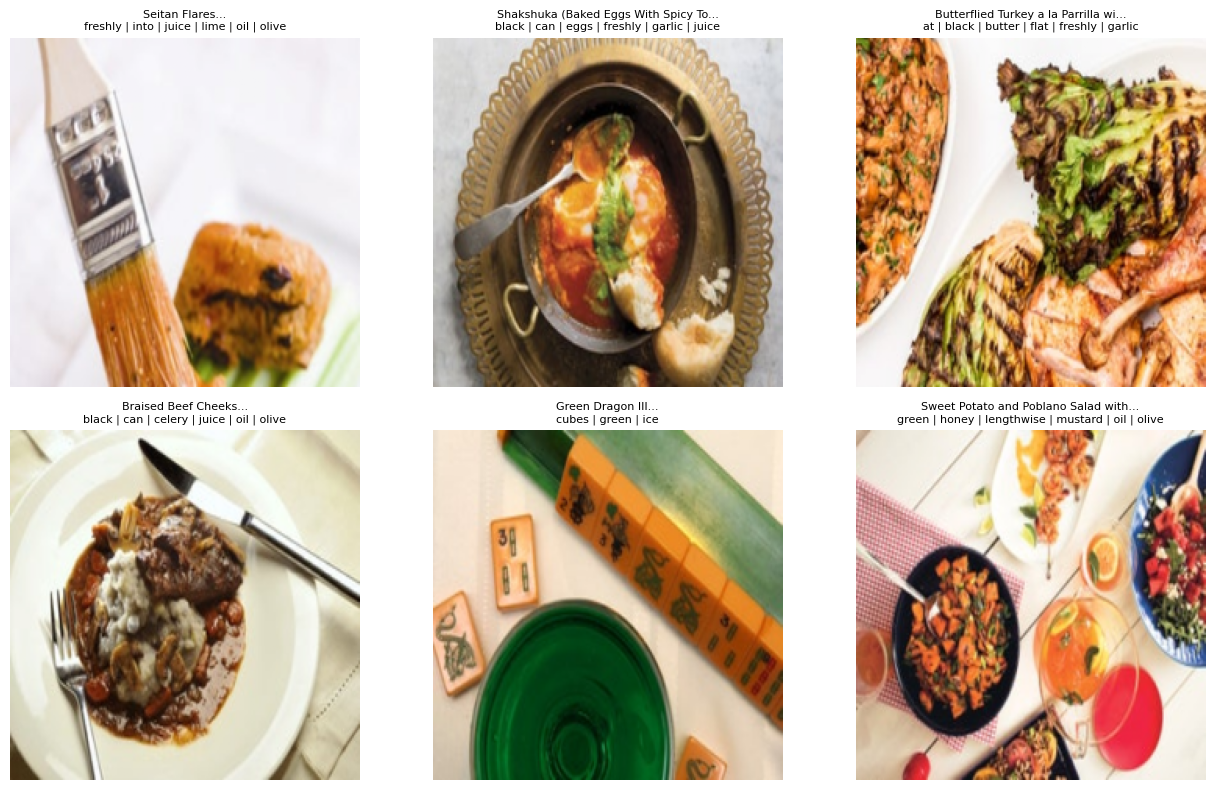

In [13]:
def denormalize(t):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

def visualize_samples(dataset, n=6):
    idxs = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    for ax, i in zip(axes.flatten(), idxs):
        img, lbl, title = dataset[i]
        ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
        present = [idx_to_ingredient[j] for j in lbl.nonzero(as_tuple=True)[0].tolist()]
        ax.set_title(f'{title[:35]}...\n{" | ".join(present[:6])}', fontsize=8)
        ax.axis('off')
    plt.tight_layout(); plt.show()

visualize_samples(val_ds, n=6)


## 1.6 Model Architecture — ResNet18 Ingredient Predictor

The baseline model uses a pretrained `ResNet18` backbone and replaces the final classification layer with a custom multi-label head.

### Design choices

- **Backbone:** ResNet18 pretrained on ImageNet.
- **Task type:** multi-label classification.
- **Output size:** number of ingredients in the vocabulary.
- **Activation:** sigmoid is applied only during inference/evaluation, not inside the model.
- **Loss:** `BCEWithLogitsLoss`, which expects raw logits.

This architecture is intentionally simple. The goal is not to build the most advanced CNN possible, but to create a clear and reproducible baseline for comparison with web-mined labels and VLM outputs.


In [14]:
class IngredientPredictor(nn.Module):
    def __init__(self, num_ingredients, backbone='resnet18', pretrained=True, freeze_backbone=True):
        super().__init__()
        self.backbone_name = backbone

        if backbone == 'resnet18':
            # Compatible with both newer and older torchvision versions.
            try:
                weights = models.ResNet18_Weights.DEFAULT if pretrained else None
                self.backbone = models.resnet18(weights=weights)
            except Exception:
                self.backbone = models.resnet18(pretrained=pretrained)

            if freeze_backbone:
                for param in self.backbone.parameters():
                    param.requires_grad = False

            in_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Linear(in_features, num_ingredients)

        elif backbone == 'efficientnet_b0':
            try:
                weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
                self.backbone = models.efficientnet_b0(weights=weights)
            except Exception:
                self.backbone = models.efficientnet_b0(pretrained=pretrained)

            if freeze_backbone:
                for param in self.backbone.parameters():
                    param.requires_grad = False

            in_features = self.backbone.classifier[-1].in_features
            self.backbone.classifier[-1] = nn.Linear(in_features, num_ingredients)

        else:
            raise ValueError("Backbone harus 'resnet18' atau 'efficientnet_b0'")

    def forward(self, x):
        # Return logits with shape (batch_size, num_ingredients)
        # The model returns logits; sigmoid is applied during evaluation or inference.
        return self.backbone(x)

# Instantiate the model and verify output shape
model_test = IngredientPredictor(num_ingredients=num_ingredients).to(DEVICE)
dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
out = model_test(dummy)
print('Output shape:', out.shape, '(seharusnya [2,', num_ingredients, '])')


Output shape: torch.Size([2, 100]) (seharusnya [2, 100 ])


## 1.7 Loss Function — Class-Imbalance-Aware BCEWithLogitsLoss

Ingredient labels are highly imbalanced. Common ingredients appear in many recipes, while rare ingredients appear only a few times.

Without class weighting, the model may learn to ignore rare labels because predicting `0` for most labels already gives a low loss. To reduce this issue, the notebook computes a positive-class weight for each ingredient and passes it to `BCEWithLogitsLoss`.

This encourages the model to pay more attention to underrepresented ingredients, although it does not fully solve the imbalance problem.


In [15]:
# Define the class-imbalance-aware loss function
# Simple baseline alternative:
# criterion = nn.BCEWithLogitsLoss()

# pos_weight is used to handle class imbalance:
# pos_counts = torch.zeros(num_ingredients)
# for _, lbl, _ in train_ds:
#     pos_counts += lbl
# neg_counts = len(train_ds) - pos_counts
# pos_weight = (neg_counts / pos_counts.clamp(min=1)).to(DEVICE)
# criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

pos_counts = torch.zeros(num_ingredients, dtype=torch.float32)
for toks in df_train['ingredients_tokens']:
    for tok in toks:
        if tok in ingredient_to_idx:
            pos_counts[ingredient_to_idx[tok]] += 1

neg_counts = len(df_train) - pos_counts

# Clamp agar class yang sangat langka tidak menghasilkan bobot ekstrem dan training tetap stabil.
pos_weight = (neg_counts / pos_counts.clamp(min=1)).clamp(max=20.0).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print('Loss function:', criterion)
print('pos_weight min/mean/max:', float(pos_weight.min()), float(pos_weight.mean()), float(pos_weight.max()))
assert criterion is not None, 'this step: pilih loss function'


Loss function: BCEWithLogitsLoss()
pos_weight min/mean/max: 0.4927286207675934 11.02657413482666 20.0



**Design decision — Loss function**

I use `BCEWithLogitsLoss(pos_weight=...)` because this is a **multi-label classification** task: every ingredient is predicted independently as present or absent. `BCEWithLogitsLoss` is also more numerically stable than applying sigmoid and binary cross entropy separately.

The `pos_weight` term is added because the ingredient distribution is imbalanced. Common ingredients such as salt, oil, pepper, and sugar appear much more frequently than less common ingredients. Without weighting, the model can minimize loss by focusing on frequent labels and ignoring rare ones. `pos_weight` helps rare ingredients contribute more to the loss, improving recall for underrepresented labels.


## 1.8 Training Function — `train_one_epoch`

This function performs one full training pass over the dataset.

For each batch, it:

1. moves images and labels to the selected device,
2. runs the CNN forward pass,
3. computes multi-label binary cross-entropy loss,
4. backpropagates the gradients,
5. updates model weights,
6. accumulates the average training loss.

The function is kept separate from the main training loop so the notebook is easier to read and reuse.


In [16]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    n_samples = 0
    for batch in loader:
        imgs, labels, _ = batch
        imgs = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        batch_size = imgs.size(0)
        total_loss += loss.item() * batch_size
        n_samples += batch_size

    return total_loss / max(n_samples, 1)


## 1.9 Evaluation Function — Loss, Precision, Recall, and F1

The evaluation function measures how well the model predicts ingredients on the validation set.

Because this is a multi-label problem, the model first outputs probabilities for each ingredient. These probabilities are converted into binary predictions using a threshold.

The notebook reports:

- **micro-F1:** overall label-level balance between precision and recall,
- **macro-F1:** average F1 across ingredients, sensitive to rare labels,
- **micro-precision:** how many predicted ingredients are correct,
- **micro-recall:** how many true ingredients are recovered,
- **validation loss:** optimization metric for training monitoring.


In [17]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0
    n_samples = 0
    all_preds = []
    all_labels = []

    for batch in loader:
        imgs, labels, _ = batch
        imgs = imgs.to(device)
        labels = labels.to(device)

        logits = model(imgs)
        loss = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        n_samples += imgs.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).int()

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy().astype(int))

    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_labels)

    micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    micro_precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
    micro_recall = recall_score(y_true, y_pred, average='micro', zero_division=0)

    return {
        'loss': total_loss / max(n_samples, 1),
        'micro_f1': micro_f1,
        'macro_f1': macro_f1,
        'micro_precision': micro_precision,
        'micro_recall': micro_recall,
    }


## 1.10 Training Loop

The training loop combines the model, optimizer, loss function, and evaluation function.

At the end of each epoch, the notebook records training loss and validation metrics. The best model checkpoint is selected based on validation micro-F1 because this metric directly reflects multi-label prediction quality.

The saved checkpoint is used later for Indonesian zero-shot transfer and CNN-vs-VLM comparison.


In [18]:
EPOCHS = 8
LR = 5e-4

model = IngredientPredictor(num_ingredients=num_ingredients, backbone='resnet18', pretrained=True, freeze_backbone=True).to(DEVICE)
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=1e-4)

history = []
best_f1 = 0.0
CKPT_PATH = "/kaggle/working/best_ingredient_model.pt"

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    tr_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_metrics = evaluate(model, val_loader, criterion, DEVICE, threshold=0.5)

    row = {
        'epoch': epoch,
        'train_loss': tr_loss,
        'val_loss': val_metrics['loss'],
        'val_micro_f1': val_metrics['micro_f1'],
        'val_macro_f1': val_metrics['macro_f1'],
        'val_micro_precision': val_metrics['micro_precision'],
        'val_micro_recall': val_metrics['micro_recall'],
    }
    history.append(row)

    if val_metrics['micro_f1'] > best_f1:
        best_f1 = val_metrics['micro_f1']
        torch.save({
            'model_state_dict': model.state_dict(),
            'ingredient_to_idx': ingredient_to_idx,
            'idx_to_ingredient': idx_to_ingredient,
            'all_ingredients': ALL_INGREDIENTS,
            'vocab_size': VOCAB_SIZE,
            'backbone': 'resnet18',
            'best_micro_f1': best_f1,
            'best_threshold': 0.5,
        }, CKPT_PATH)

    elapsed = time.time() - start_time
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={tr_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"micro_f1={val_metrics['micro_f1']:.4f} | "
        f"macro_f1={val_metrics['macro_f1']:.4f} | "
        f"precision={val_metrics['micro_precision']:.4f} | "
        f"recall={val_metrics['micro_recall']:.4f} | "
        f"time={elapsed:.1f}s"
    )

print('Best validation micro-F1:', best_f1)
print('Checkpoint saved to:', CKPT_PATH)

history_df = pd.DataFrame(history)
history_df


Epoch 01/8 | train_loss=1.1727 | val_loss=1.1097 | micro_f1=0.2871 | macro_f1=0.2598 | precision=0.1867 | recall=0.6216 | time=44.8s
Epoch 02/8 | train_loss=1.1082 | val_loss=1.0942 | micro_f1=0.2936 | macro_f1=0.2678 | precision=0.1928 | recall=0.6157 | time=45.6s
Epoch 03/8 | train_loss=1.0867 | val_loss=1.0893 | micro_f1=0.3128 | macro_f1=0.2737 | precision=0.2080 | recall=0.6309 | time=45.9s
Epoch 04/8 | train_loss=1.0736 | val_loss=1.0889 | micro_f1=0.2967 | macro_f1=0.2724 | precision=0.1961 | recall=0.6088 | time=46.3s
Epoch 05/8 | train_loss=1.0670 | val_loss=1.0915 | micro_f1=0.3034 | macro_f1=0.2737 | precision=0.2012 | recall=0.6166 | time=46.0s
Epoch 06/8 | train_loss=1.0609 | val_loss=1.0903 | micro_f1=0.3110 | macro_f1=0.2765 | precision=0.2049 | recall=0.6454 | time=46.8s
Epoch 07/8 | train_loss=1.0560 | val_loss=1.0907 | micro_f1=0.3105 | macro_f1=0.2762 | precision=0.2068 | recall=0.6222 | time=45.8s
Epoch 08/8 | train_loss=1.0519 | val_loss=1.0909 | micro_f1=0.3080 | 

,epoch,train_loss,val_loss,val_micro_f1,val_macro_f1,val_micro_precision,val_micro_recall
0,1,1.172653,1.109710,0.287102,0.259819,0.186656,0.621610
1,2,1.108225,1.094168,0.293589,0.267755,0.192750,0.615699
2,3,1.086729,1.089344,0.312825,0.273690,0.207976,0.630873
3,4,1.073601,1.088939,0.296672,0.272395,0.196121,0.608812
4,5,1.067018,1.091533,0.303361,0.273687,0.201165,0.616613
5,6,1.060945,1.090261,0.310995,0.276538,0.204855,0.645378
6,7,1.055960,1.090680,0.310464,0.276247,0.206840,0.622159
7,8,1.051905,1.090911,0.308045,0.275252,0.204279,0.626059


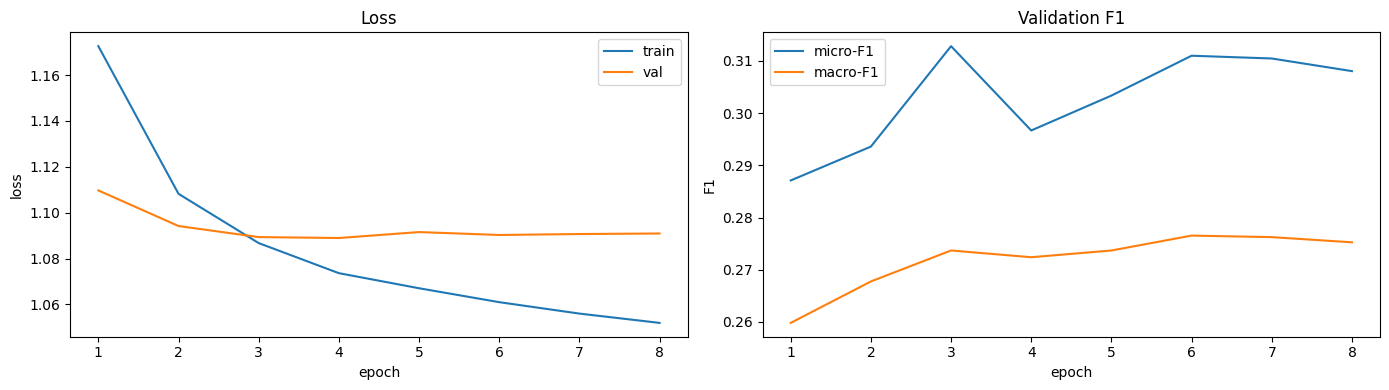

In [19]:
# Plot kurva training (run after the training loop completes)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend(); axes[0].set_title('Loss')

axes[1].plot(history_df['epoch'], history_df['val_micro_f1'], label='micro-F1')
axes[1].plot(history_df['epoch'], history_df['val_macro_f1'], label='macro-F1')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('F1'); axes[1].legend(); axes[1].set_title('Validation F1')
plt.tight_layout(); plt.show()


## 1.11 Threshold Tuning

A multi-label model produces probabilities, not final labels. The threshold controls how strict the model is when deciding whether an ingredient is present.

A low threshold increases recall but may produce many false positives. A high threshold increases precision but may miss many true ingredients.

This section sweeps several threshold values and selects the one that gives the best validation micro-F1. This threshold is then reused in later phases for fairer comparison.


Loaded best checkpoint from: /kaggle/working/best_ingredient_model.pt
threshold=0.1 | micro_f1=0.2226 | precision=0.1253 | recall=0.9965
threshold=0.2 | micro_f1=0.2379 | precision=0.1355 | recall=0.9750
threshold=0.3 | micro_f1=0.2603 | precision=0.1517 | recall=0.9147
threshold=0.4 | micro_f1=0.2879 | precision=0.1755 | recall=0.8010
threshold=0.5 | micro_f1=0.3128 | precision=0.2080 | recall=0.6309
threshold=0.6 | micro_f1=0.3202 | precision=0.2528 | recall=0.4366
threshold=0.7 | micro_f1=0.2774 | precision=0.3155 | recall=0.2474
threshold=0.8 | micro_f1=0.1625 | precision=0.3987 | recall=0.1021
threshold=0.9 | micro_f1=0.0346 | precision=0.4892 | recall=0.0179


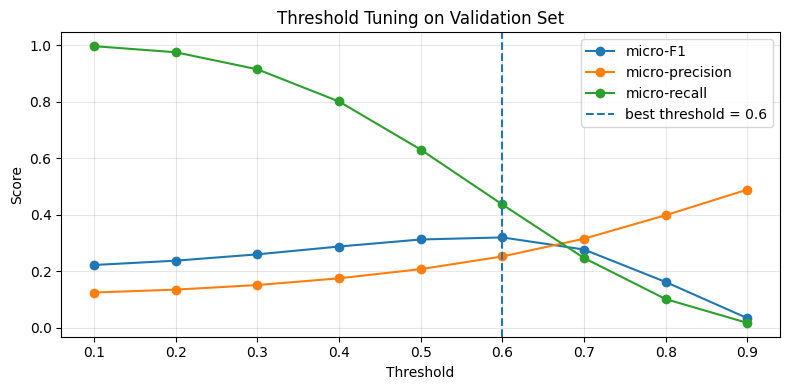

BEST_THRESHOLD: 0.6


In [20]:
# Sweep thresholds and plot micro-F1
# Hint: panggil evaluate(model, val_loader, criterion, DEVICE, threshold=t) untuk t = 0.1, 0.2, ..., 0.9
# Plot t vs micro_f1, pilih t terbaik, simpan ke variabel BEST_THRESHOLD

if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    print('Loaded best checkpoint from:', CKPT_PATH)

thresholds = np.arange(0.1, 1.0, 0.1)
threshold_results = []

for t in thresholds:
    metrics = evaluate(model, val_loader, criterion, DEVICE, threshold=float(t))
    threshold_results.append({
        'threshold': float(t),
        'micro_f1': metrics['micro_f1'],
        'macro_f1': metrics['macro_f1'],
        'micro_precision': metrics['micro_precision'],
        'micro_recall': metrics['micro_recall'],
    })
    print(
        f"threshold={t:.1f} | "
        f"micro_f1={metrics['micro_f1']:.4f} | "
        f"precision={metrics['micro_precision']:.4f} | "
        f"recall={metrics['micro_recall']:.4f}"
    )

threshold_df = pd.DataFrame(threshold_results)
best_row = threshold_df.loc[threshold_df['micro_f1'].idxmax()]
BEST_THRESHOLD = float(best_row['threshold'])

plt.figure(figsize=(8, 4))
plt.plot(threshold_df['threshold'], threshold_df['micro_f1'], marker='o', label='micro-F1')
plt.plot(threshold_df['threshold'], threshold_df['micro_precision'], marker='o', label='micro-precision')
plt.plot(threshold_df['threshold'], threshold_df['micro_recall'], marker='o', label='micro-recall')
plt.axvline(BEST_THRESHOLD, linestyle='--', label=f'best threshold = {BEST_THRESHOLD:.1f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning on Validation Set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('BEST_THRESHOLD:', BEST_THRESHOLD)
threshold_df

# Update the checkpoint with the best threshold.
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location='cpu')
    ckpt['best_threshold'] = BEST_THRESHOLD
    torch.save(ckpt, CKPT_PATH)


## 1.12 Error Analysis — False Positives and False Negatives

Aggregate metrics are useful, but they do not explain what the model gets wrong. This section visualizes individual validation samples and compares:

- ground-truth recipe ingredients,
- predicted ingredients,
- false positives,
- false negatives,
- high-probability ingredients near the threshold.

This helps identify whether errors are caused by visually hidden ingredients, label noise, ambiguous images, or model confusion.


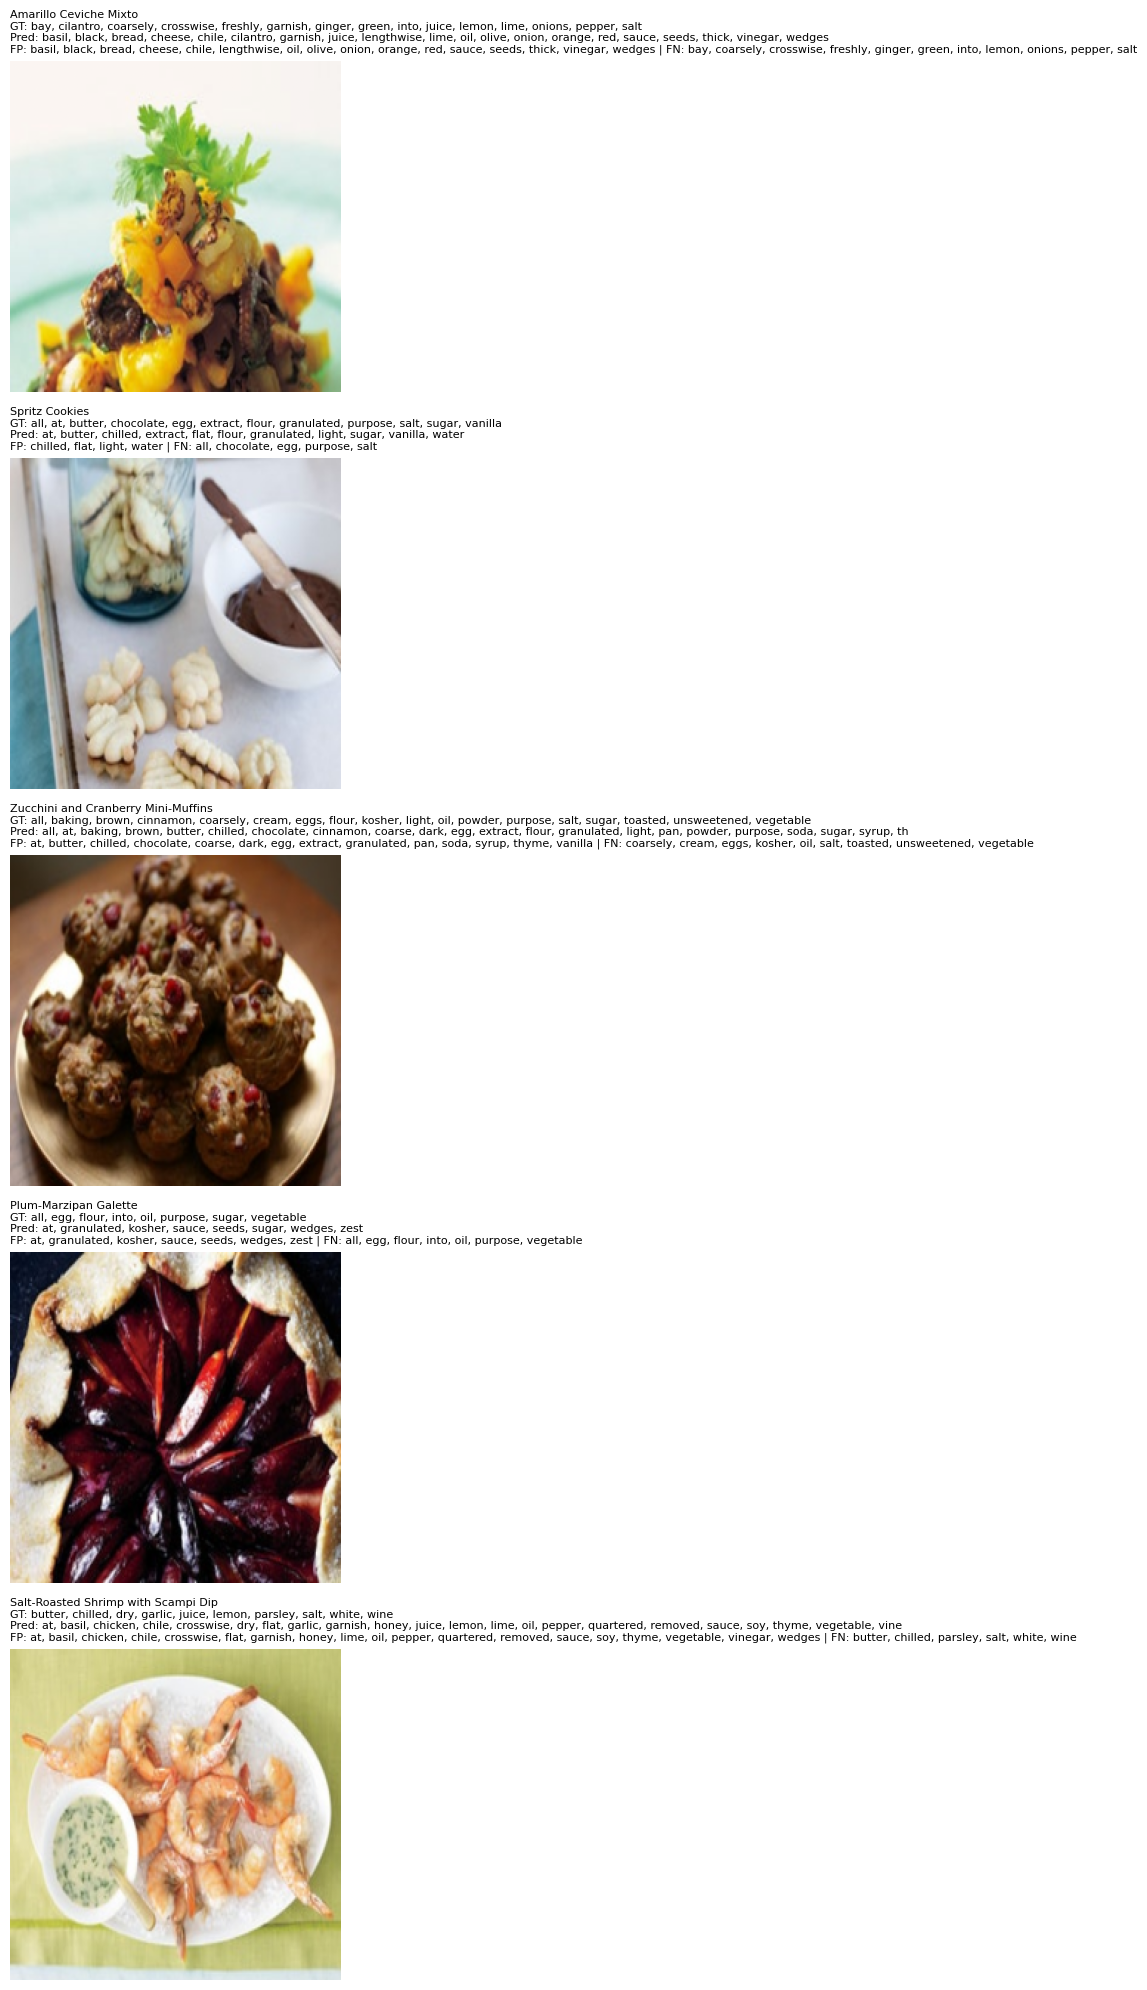

,title,ground_truth,predicted,false_positive,false_negative,top_probabilities
0,Amarillo Ceviche Mixto,"bay, cilantro, coarsely, crosswise, freshly, g...","basil, black, bread, cheese, chile, cilantro, ...","basil, black, bread, cheese, chile, lengthwise...","bay, coarsely, crosswise, freshly, ginger, gre...","basil:0.78, lime:0.78, black:0.74, oil:0.73, b..."
1,Spritz Cookies,"all, at, butter, chocolate, egg, extract, flou...","at, butter, chilled, extract, flat, flour, gra...","chilled, flat, light, water","all, chocolate, egg, purpose, salt","at:0.78, vanilla:0.77, chilled:0.71, extract:0..."
2,Zucchini and Cranberry Mini-Muffins,"all, baking, brown, cinnamon, coarsely, cream,...","all, at, baking, brown, butter, chilled, choco...","at, butter, chilled, chocolate, coarse, dark, ...","coarsely, cream, eggs, kosher, oil, salt, toas...","baking:0.92, vanilla:0.91, soda:0.90, chilled:..."
3,Plum-Marzipan Galette,"all, egg, flour, into, oil, purpose, sugar, ve...","at, granulated, kosher, sauce, seeds, sugar, w...","at, granulated, kosher, sauce, seeds, wedges, ...","all, egg, flour, into, oil, purpose, vegetable","seeds:0.68, sauce:0.65, sugar:0.64, wedges:0.6..."
4,Salt-Roasted Shrimp with Scampi Dip,"butter, chilled, dry, garlic, juice, lemon, pa...","at, basil, chicken, chile, crosswise, dry, fla...","at, basil, chicken, chile, crosswise, flat, ga...","butter, chilled, parsley, salt, white, wine","pepper:0.78, at:0.75, dry:0.75, crosswise:0.73..."


In [21]:
# Visualize error analysis samples

if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    BEST_THRESHOLD = float(ckpt.get('best_threshold', BEST_THRESHOLD))

model.eval()


def label_indices_to_names(indices):
    return [idx_to_ingredient[int(i)] for i in indices]


def label_vector_to_names(label_tensor):
    indices = label_tensor.nonzero(as_tuple=True)[0].tolist()
    return label_indices_to_names(indices)

n_samples = min(5, len(val_ds))
sample_indices = random.sample(range(len(val_ds)), n_samples)
error_rows = []

fig, axes = plt.subplots(n_samples, 1, figsize=(11, 4 * n_samples))
if n_samples == 1:
    axes = [axes]

with torch.no_grad():
    for ax, sample_idx in zip(axes, sample_indices):
        img, true_label, title = val_ds[sample_idx]
        logits = model(img.unsqueeze(0).to(DEVICE))
        probs = torch.sigmoid(logits).squeeze(0).cpu()
        pred_label = (probs >= BEST_THRESHOLD).int()

        gt_names = set(label_vector_to_names(true_label))
        pred_names = set(label_vector_to_names(pred_label))
        fp = sorted(pred_names - gt_names)
        fn = sorted(gt_names - pred_names)

        # Top probability ditampilkan untuk membantu interpretasi meskipun tidak melewati threshold.
        topk = min(8, len(idx_to_ingredient))
        top_probs_idx = torch.topk(probs, k=topk).indices.tolist()
        top_probs = [(idx_to_ingredient[i], float(probs[i])) for i in top_probs_idx]

        error_rows.append({
            'title': title,
            'ground_truth': ', '.join(sorted(gt_names)),
            'predicted': ', '.join(sorted(pred_names)) if pred_names else '(none)',
            'false_positive': ', '.join(fp) if fp else '-',
            'false_negative': ', '.join(fn) if fn else '-',
            'top_probabilities': ', '.join([f'{name}:{prob:.2f}' for name, prob in top_probs]),
        })

        ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
        ax.axis('off')
        ax.set_title(
            f"{title}\n"
            f"GT: {', '.join(sorted(gt_names))[:160]}\n"
            f"Pred: {', '.join(sorted(pred_names))[:160] if pred_names else '(none)'}\n"
            f"FP: {', '.join(fp)[:160] if fp else '-'} | FN: {', '.join(fn)[:160] if fn else '-'}",
            fontsize=8,
            loc='left'
        )

plt.tight_layout(); plt.show()

error_analysis_df = pd.DataFrame(error_rows)
error_analysis_df



**Error analysis summary**

The Phase 1 model works as a reasonable CNN baseline for multi-label ingredient prediction. The best validation micro-F1 at the default threshold was **0.3128**, with precision **0.2080** and recall **0.6309**. After threshold tuning, the best threshold was **0.6**, improving micro-F1 to **0.3202** with precision **0.2528** and recall **0.4366**.

This threshold shift shows the expected precision–recall trade-off. At threshold 0.5, the model predicts more ingredients and captures more true labels, but it also creates many false positives. Raising the threshold to 0.6 makes predictions more conservative, improving precision and overall micro-F1.

The main error pattern is that the model often predicts common or visually plausible ingredients such as oil, pepper, salt, garlic, basil, or tomatoes. False negatives often occur for ingredients that are hidden inside the dish, only mentioned in the recipe text, or visually indistinguishable in the final food image. This is an important limitation for ingredient recognition: image-only supervision cannot perfectly recover non-visible ingredients.


---

# Phase 2 — Zero-Shot Transfer to Indonesian Food Images

Phase 2 tests whether the CNN trained on the Phase 1 recipe dataset can transfer to Indonesian food images without additional Indonesian training.

This is a difficult setting because Indonesian dishes introduce two problems:

1. **Visual domain shift**  
   Dishes such as Rendang, Rawon, Soto, Gado-Gado, and Sate may look different from the global food images used in Phase 1.

2. **Label-space mismatch**  
   Important Indonesian ingredients such as `santan`, `terasi`, `kemiri`, `daun jeruk`, and `kluwek` may not exist in the Phase 1 output vocabulary.

This phase is therefore not expected to produce perfect results. Its purpose is to diagnose how far the baseline can transfer and what limitations need to be addressed.


In [22]:
INDO_DATASET_DIR = resolve_dataset_dir(
    kaggle_slug="rizkyyk/dataset-food-classification",
    local_dir="data/raw/dataset-food-classification",
    kaggle_hints=[
        "dataset-food-classification",
        "food-classification",
        "indonesian-food",
    ],
)

print_directory_preview(INDO_DATASET_DIR, max_depth=2, max_files=3)


Dataset not found locally. Downloading with kagglehub: rizkyyk/dataset-food-classification
Dataset folder: /kaggle/input/datasets/rizkyyk/dataset-food-classification
dataset-food-classification/
  dataset_gambar/


In [23]:
all_indo_images = []
for p in Path(INDO_DATASET_DIR).rglob("*"):
    if p.suffix.lower() in IMG_EXTS:
        all_indo_images.append(p)

rows = []
for p in all_indo_images:
    food_class = p.parent.name
    rows.append({"image_path": p, "food_class": food_class})

df_indo = pd.DataFrame(rows)
print("Indonesian images:", len(df_indo))
print("Number of classes:", df_indo["food_class"].nunique())
display(df_indo.head())

indo_classes = sorted(df_indo["food_class"].unique())
print("Classes:", indo_classes[:20])


Indonesian images: 6490
Number of classes: 13


,image_path,food_class
0,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,Sate
1,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,Sate
2,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,Sate
3,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,Sate
4,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,Sate


Classes: ['Ayam Goreng', 'Burger', 'French Fries', 'Gado-Gado', 'Ikan Goreng', 'Mie Goreng', 'Nasi Goreng', 'Nasi Padang', 'Pizza', 'Rawon', 'Rendang', 'Sate', 'Soto']


In [24]:
class IndonesianFoodImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.paths = list(image_paths)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, path.parent.name, str(path)

indo_ds = IndonesianFoodImageDataset(all_indo_images, test_transform)
print(f'Indo dataset size: {len(indo_ds)}')


Indo dataset size: 6490


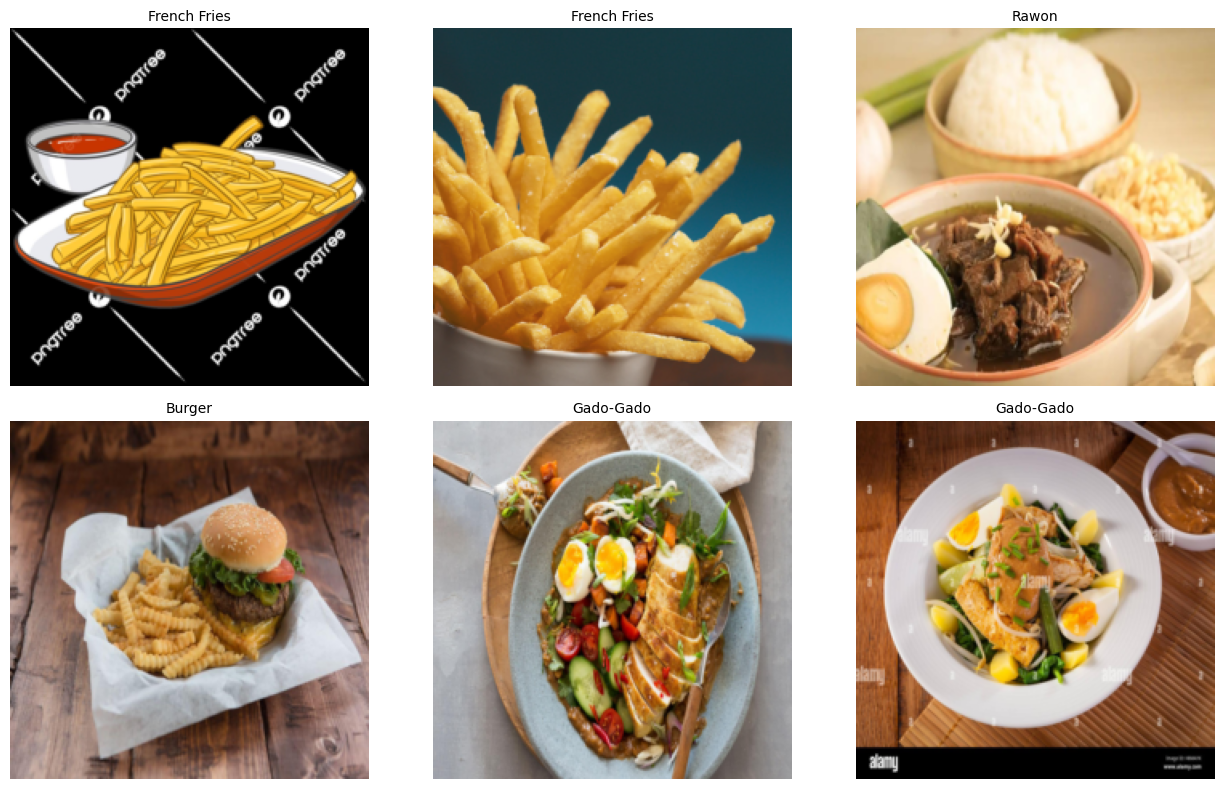

In [25]:
def visualize_indo_samples(dataset, n=6):
    idxs = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    for ax, i in zip(axes.flatten(), idxs):
        img, cls, _ = dataset[i]
        ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
        ax.set_title(cls, fontsize=10)
        ax.axis('off')
    plt.tight_layout(); plt.show()

visualize_indo_samples(indo_ds, n=6)


## 2.1 Zero-Shot Inference with the Phase 1 Checkpoint

This section loads the best Phase 1 CNN checkpoint and applies it directly to Indonesian food images.

The model has never been trained on these Indonesian class labels. It can only output ingredients from the Phase 1 vocabulary, so its predictions should be interpreted as approximate transferable ingredient guesses rather than final ground truth.

The results are useful for identifying:

- ingredients that transfer well across cuisines,
- ingredients the CNN overpredicts,
- classes where the fixed vocabulary is too limited,
- visual patterns that confuse the model.


In [26]:
# Load checkpoint and run zero-shot Indonesian inference

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)

model = IngredientPredictor(
    num_ingredients=num_ingredients,
    backbone=ckpt.get('backbone', 'resnet18'),
    pretrained=False,
    freeze_backbone=True
).to(DEVICE)

model.load_state_dict(ckpt['model_state_dict'])
model.eval()

BEST_THRESHOLD = ckpt.get('best_threshold', BEST_THRESHOLD)

print('Loaded checkpoint from:', CKPT_PATH)
print('Backbone:', ckpt.get('backbone', 'resnet18'))
print('Best threshold:', BEST_THRESHOLD)

@torch.no_grad()
def predict_indo_single(model, image_tensor, threshold=0.5):
    model.eval()

    if image_tensor.dim() == 3:
        image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.to(DEVICE)

    logits = model(image_tensor)
    probs = torch.sigmoid(logits).cpu().squeeze(0).numpy()

    pred_idx = np.where(probs >= threshold)[0]
    predicted_ingredients = [idx_to_ingredient[i] for i in pred_idx]

    return predicted_ingredients, probs



# Test pada beberapa sample
# img, cls, path = indo_ds[0]
# ings, probs = predict_indo_single(model, img.unsqueeze(0).to(DEVICE), threshold=BEST_THRESHOLD)
# print(f'{cls} → {ings}')
img, cls, path = indo_ds[0]

ings, probs = predict_indo_single(
    model,
    img.unsqueeze(0).to(DEVICE),
    threshold=BEST_THRESHOLD
)

print(f'{cls} -> {ings}')

topk_idx = np.argsort(probs)[::-1][:10]
print('Top-10 probabilities:')
for i in topk_idx:
    print(f'{idx_to_ingredient[i]:15s} {probs[i]:.4f}')


Loaded checkpoint from: /kaggle/working/best_ingredient_model.pt
Backbone: resnet18
Best threshold: 0.6
Sate -> ['basil', 'black', 'boneless', 'bread', 'coarsely', 'crushed', 'dry', 'flakes', 'garlic', 'oil', 'olive', 'pepper', 'quartered', 'red', 'removed', 'salt', 'sauce', 'seeds', 'thick', 'thyme', 'tomatoes', 'wine']
Top-10 probabilities:
tomatoes        0.7805
seeds           0.7628
pepper          0.7615
basil           0.7470
olive           0.7212
thyme           0.7209
garlic          0.7173
red             0.7135
flakes          0.6888
black           0.6832


In [27]:
def visualize_indo_predictions(model, dataset, n=6, threshold=0.5, topk=5):
    idxs = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for ax, i in zip(axes.flatten(), idxs):
        img, cls, _ = dataset[i]
        ings, probs = predict_indo_single(model, img.unsqueeze(0).to(DEVICE), threshold=threshold)
        topk_idx = np.argsort(probs)[::-1][:topk]
        topk_str = ', '.join([f'{idx_to_ingredient[j]}({probs[j]:.2f})' for j in topk_idx])
        ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
        ax.set_title(f'{cls}\nPred (≥0.5): {ings}\nTop-{topk}: {topk_str}', fontsize=7)
        ax.axis('off')
    plt.tight_layout(); plt.show()

# visualize_indo_predictions(model, indo_ds, n=6, threshold=BEST_THRESHOLD)


## 2.2 Manual Weak Labels for Qualitative Evaluation

Since the Indonesian food dataset is organized by food class rather than ingredient-level labels, this section defines approximate ingredient labels manually for each class.

These labels are called **weak labels** because they are not verified per image. For example, not every image of `Nasi Goreng` will show exactly the same ingredients, but a class-level mapping can still provide a useful evaluation signal.

The mapping should be interpreted carefully:

- it is class-level, not image-level,
- it only uses ingredients available in the Phase 1 vocabulary,
- it prioritizes common representative ingredients,
- it is meant for diagnostic evaluation, not a definitive benchmark.


In [28]:
# Seed mapping — lengkapi sendiri untuk semua kelas di indo_classes!
# Gunakan HANYA ingredient yang ada di ALL_INGREDIENTS (vocab Phase 1).
# Periksa dulu apa saja yang ada: print([x for x in ALL_INGREDIENTS if 'rice' in x or 'chicken' in x])

INDO_FOOD_TO_INGREDIENTS = {
    'Ayam Goreng': [
        'chicken', 'oil', 'flour', 'garlic', 'salt', 'pepper', 'egg'
    ],

    'Burger': [
        'bread', 'beef', 'cheese', 'onion', 'tomato', 'mayonnaise',
        'mustard', 'sauce'
    ],

    'French Fries': [
        'potatoes', 'oil', 'salt', 'pepper'
    ],

    'Gado-Gado': [
        'egg', 'eggs', 'beans', 'carrots', 'potatoes', 'sauce'
    ],

    'Ikan Goreng': [
        'oil', 'flour', 'garlic', 'salt', 'pepper', 'lemon', 'lime'
    ],

    'Mie Goreng': [
        'egg', 'eggs', 'chicken', 'garlic', 'onion', 'onions',
        'soy', 'oil', 'vegetable', 'scallions'
    ],

    'Nasi Goreng': [
        'rice', 'egg', 'eggs', 'chicken', 'garlic', 'onion',
        'onions', 'soy', 'oil', 'scallions'
    ],

    'Nasi Padang': [
        'rice', 'beef', 'chicken', 'egg', 'eggs', 'coconut',
        'garlic', 'onion', 'chile', 'chiles', 'pepper'
    ],

    'Pizza': [
        'bread', 'flour', 'cheese', 'tomato', 'tomatoes', 'sauce',
        'basil', 'oregano', 'onion', 'pepper', 'olive'
    ],

    'Rawon': [
        'beef', 'broth', 'garlic', 'onion', 'pepper', 'water'
    ],

    'Rendang': [
        'beef', 'coconut', 'garlic', 'onion', 'ginger',
        'chile', 'chiles', 'oil'
    ],

    'Sate': [
        'chicken', 'beef', 'soy', 'garlic', 'oil', 'sauce'
    ],

    'Soto': [
        'chicken', 'broth', 'egg', 'eggs', 'rice', 'garlic',
        'onion', 'lemon', 'lime', 'scallions'
    ],
}

# Filter: keep hanya token yang ada di vocab
INDO_FOOD_TO_INGREDIENTS = {
    k: [t for t in v if t in ingredient_to_idx]
    for k, v in INDO_FOOD_TO_INGREDIENTS.items()
}

# Periksa coverage
missing_classes = [c for c in indo_classes if c not in INDO_FOOD_TO_INGREDIENTS]
print(f'Kelas tanpa mapping: {missing_classes}')


Kelas tanpa mapping: []



## 2.3 Out-of-Vocabulary Analysis

The Phase 1 model can only predict ingredients that exist in its fixed output vocabulary. Many culturally important Indonesian ingredients are therefore impossible for the model to output.

Examples of Indonesian ingredients that are not explicitly represented in the Phase 1 vocabulary:

- `santan` / coconut milk,
- `lengkuas` / galangal,
- `kunyit` / turmeric,
- `terasi` / shrimp paste,
- `daun jeruk` / kaffir lime leaf,
- `serai` / lemongrass,
- `kemiri` / candlenut,
- `kecap manis` / sweet soy sauce,
- `daun salam` / Indonesian bay leaf,
- `petis` / fermented shrimp paste.

This creates a **label-space mismatch**. Even if the image contains a culturally important ingredient, the CNN cannot predict it because there is no output neuron for that label. This limitation is separate from visual difficulty; it is a structural limitation of the vocabulary.



## 2.4 Weak Quantitative Evaluation

The CNN is evaluated against the manual weak labels from the previous section. This is not a true ground-truth evaluation, but it helps estimate:

- whether the CNN recognizes common transferable ingredients,
- how severe the domain shift is,
- how much the fixed vocabulary limits Indonesian food understanding.

The resulting micro-F1 is interpreted as an approximate diagnostic metric, not as a final benchmark score.


In [29]:
# Evaluate the CNN using manual weak labels on indo_ds

from torch.utils.data import DataLoader

@torch.no_grad()
def evaluate_indo_manual_weak_labels_fast(model, dataset, label_dict, threshold=0.5, batch_size=64):
    model.eval()

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    all_preds = []
    all_labels = []

    for imgs, classes, paths in loader:
        keep_indices = [
            i for i, cls in enumerate(classes)
            if cls in label_dict and len(label_dict[cls]) > 0
        ]

        if len(keep_indices) == 0:
            continue

        imgs_keep = imgs[keep_indices].to(DEVICE)

        logits = model(imgs_keep)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= threshold).astype(int)

        labels = []

        for i in keep_indices:
            cls = classes[i]
            gt = np.zeros(num_ingredients, dtype=int)

            for ing in label_dict[cls]:
                gt[ingredient_to_idx[ing]] = 1

            labels.append(gt)

        all_preds.append(preds)
        all_labels.append(np.stack(labels))

    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_labels)

    return {
        'micro_f1': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'micro_precision': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'micro_recall': recall_score(y_true, y_pred, average='micro', zero_division=0),
    }


weak_eval_result = evaluate_indo_manual_weak_labels_fast(
    model=model,
    dataset=indo_ds,
    label_dict=INDO_FOOD_TO_INGREDIENTS,
    threshold=BEST_THRESHOLD,
    batch_size=64
)

weak_eval_result


{'micro_f1': 0.19689771845110512,
 'micro_precision': 0.12611406806056777,
 'micro_recall': 0.44878700200311594}


---

# Phase 3 — Web/Text Mining for Weak Ingredient Labels

Manual weak labels are useful but slow and subjective. Phase 3 builds an automated weak-label generator using web/text mining.

## Workflow

1. Search ingredient-related evidence for each Indonesian food class using queries such as:
   - `"nasi goreng ingredients"`,
   - `"resep nasi goreng"`,
   - `"bakso ingredients"`.
2. Collect textual evidence from titles, snippets, and recipe descriptions.
3. Extract candidate ingredients using regex, keyword matching, and bilingual ingredient dictionaries.
4. Count ingredient frequency per food class.
5. Filter candidates using `MIN_COUNT` and `TOP_K_PER_FOOD`.
6. Use the resulting weak labels to evaluate the CNN on Indonesian food images.

This phase demonstrates weak supervision: using noisy external text evidence to create approximate labels when manually annotated data is unavailable.


In [31]:
try:
    INDO_RECIPE_DIR = resolve_dataset_dir(
        kaggle_slug="albertnathaniel12/food-recipes-dataset",
        local_dir="data/raw/food-recipes-dataset",
        kaggle_hints=[
            "food-recipes-dataset",
            "food-recipes",
            "recipe-corpus",
        ],
    )

    print("Indonesian recipe corpus:", INDO_RECIPE_DIR)
    indo_recipe_csvs = list(Path(INDO_RECIPE_DIR).rglob("*.csv"))
    print("CSV files found:", indo_recipe_csvs)
except Exception as e:
    print("Optional recipe corpus unavailable. Continuing with web snippets only.")
    print("Reason:", e)
    INDO_RECIPE_DIR = None


Dataset not found locally. Downloading with kagglehub: albertnathaniel12/food-recipes-dataset
Indonesian recipe corpus: /kaggle/input/datasets/albertnathaniel12/food-recipes-dataset
CSV files found: [PosixPath('/kaggle/input/datasets/albertnathaniel12/food-recipes-dataset/Indonesian_Food_Recipes.csv')]



## 3.1 Ingredient Keyword Dictionary

A bilingual ingredient dictionary is used for keyword matching and normalization. For example:

```python
{
    "chicken": ["chicken", "ayam"],
    "beef": ["beef", "daging sapi", "sapi"],
    "egg": ["egg", "telur"],
    "rice": ["rice", "nasi"],
}
```

Each canonical ingredient can have multiple English and Indonesian surface forms. Expanding this dictionary is important because Indonesian recipes frequently use local ingredient names and spelling variations.


In [32]:
RAW_INGREDIENT_KEYWORDS = {
    'rice':         ['rice', 'nasi', 'beras'],
    'noodle':       ['noodle', 'noodles', 'mie', 'bihun', 'kwetiau'],
    'egg':          ['egg', 'eggs', 'telur'],
    'chicken':      ['chicken', 'ayam'],
    'beef':         ['beef', 'daging sapi', 'sapi'],
    'pork':         ['pork', 'babi'],
    'fish':         ['fish', 'ikan'],
    'shrimp':       ['shrimp', 'prawn', 'udang'],
    'tofu':         ['tofu', 'tahu'],
    'tempeh':       ['tempeh', 'tempe'],
    'garlic':       ['garlic', 'bawang putih'],
    'onion':        ['onion', 'bawang merah', 'bawang bombay'],
    'shallot':      ['shallot', 'shallots'],
    'ginger':       ['ginger', 'jahe'],
    'galangal':     ['galangal', 'lengkuas', 'laos'],
    'turmeric':     ['turmeric', 'kunyit'],
    'lemongrass':   ['lemongrass', 'serai', 'sereh'],
    'kaffir_lime':  ['kaffir lime', 'daun jeruk'],
    'bay_leaf':     ['bay leaf', 'daun salam'],
    'candlenut':    ['candlenut', 'kemiri'],
    'coriander':    ['coriander', 'ketumbar'],
    'cumin':        ['cumin', 'jinten', 'jintan'],
    'chili':        ['chili', 'chilli', 'cabai', 'cabe'],
    'pepper':       ['pepper', 'lada', 'merica'],
    'salt':         ['salt', 'garam'],
    'sugar':        ['sugar', 'gula'],
    'palm_sugar':   ['palm sugar', 'gula merah', 'gula jawa', 'gula aren'],
    'coconut':      ['coconut', 'kelapa'],
    'coconut_milk': ['coconut milk', 'santan'],
    'soy_sauce':    ['soy sauce', 'kecap', 'kecap manis', 'kecap asin'],
    'fish_sauce':   ['fish sauce'],
    'oyster_sauce': ['oyster sauce', 'saus tiram'],
    'shrimp_paste': ['shrimp paste', 'terasi', 'belacan'],
    'tamarind':     ['tamarind', 'asam jawa', 'asam'],
    'lime':         ['lime', 'jeruk nipis'],
    'oil':          ['oil', 'minyak'],
    'butter':       ['butter', 'mentega'],
    'flour':        ['flour', 'tepung'],
    'cheese':       ['cheese', 'keju'],
    'milk':         ['milk', 'susu'],
    'tomato':       ['tomato', 'tomat'],
    'potato':       ['potato', 'kentang'],
    'carrot':       ['carrot', 'wortel'],
    'cabbage':      ['cabbage', 'kol', 'kubis'],
    'spinach':      ['spinach', 'bayam'],
    'cucumber':     ['cucumber', 'timun', 'mentimun'],
    'bean_sprouts': ['bean sprouts', 'tauge', 'taoge'],
    'green_bean':   ['green bean', 'kacang panjang'],
    'peanut':       ['peanut', 'kacang tanah', 'kacang'],
    'sesame':       ['sesame', 'wijen'],
    'corn':         ['corn', 'jagung'],
    'mushroom':     ['mushroom', 'jamur'],
    'banana':       ['banana', 'pisang'],
    'mango':        ['mango', 'mangga'],
    'pandan':       ['pandan', 'pandan leaf'],
    'cinnamon':     ['cinnamon', 'kayu manis'],
    'clove':        ['clove', 'cengkeh'],
    'nutmeg':       ['nutmeg', 'pala'],
    'vinegar':      ['vinegar', 'cuka'],
    'water':        ['water', 'air'],
    'broth':        ['broth', 'stock', 'kaldu'],
}

print(f'Total raw keywords: {len(RAW_INGREDIENT_KEYWORDS)}')


Total raw keywords: 61



## 3.2 Dictionary Expansion with Indonesian Ingredients

This section expands the initial ingredient dictionary with local ingredients and synonyms. The goal is to improve recall during web/text mining, especially for dishes that use culturally specific ingredients.

Examples of added concepts include `santan`, `terasi`, `lengkuas`, `daun jeruk`, `kemiri`, `kecap manis`, `cabai`, `serai`, `kunyit`, and `petis`.


In [33]:
# Extend RAW_INGREDIENT_KEYWORDS with Indonesian ingredient terms
STUDENT_EXTRA_KEYWORDS = {
    "petai": ["petai", "pete", "stink bean"],
    "petis": ["petis", "shrimp paste sauce"],
    "kluwek": ["kluwek", "keluwek", "keluak", "buah keluak"],
    "kencur": ["kencur", "aromatic ginger"],
    "daun_bawang": ["daun bawang", "scallion", "green onion", "spring onion"],
    "seledri": ["seledri", "celery"],
    "daun_kunyit": ["daun kunyit", "turmeric leaf"],
    "asam_kandis": ["asam kandis", "garcinia"],
    "ebi": ["ebi", "dried shrimp", "udang kering"],
    "bawang_goreng": ["bawang goreng", "fried shallot", "fried shallots"],
    "sambal": ["sambal", "chili paste", "chilli paste"],
    "lontong": ["lontong", "rice cake"],
    "kerupuk": ["kerupuk", "krupuk", "cracker", "crackers"],
    "daun_singkong": ["daun singkong", "cassava leaves", "cassava leaf"],
}

RAW_INGREDIENT_KEYWORDS.update(STUDENT_EXTRA_KEYWORDS)
print(f'Total keywords setelah extend: {len(RAW_INGREDIENT_KEYWORDS)}')


Total keywords setelah extend: 75


## 3.3 Web Mining

This section collects external text evidence for each Indonesian food class. For each food name, the notebook searches query variants such as English ingredient queries and Indonesian recipe queries.

The collected evidence usually includes titles, snippets, and URLs. These snippets are not guaranteed to be clean recipe data, so the next sections apply keyword extraction and filtering.

The purpose is to simulate a realistic weak-supervision workflow where labeled image data is unavailable, but public text evidence can still provide approximate labels.


In [34]:
from ddgs import DDGS

def clean_food_query(name):
    return name.replace('_', ' ').replace('-', ' ').strip()

def search_web_snippets(query, max_results=10, region='id-id'):
    results = []
    try:
        with DDGS() as ddgs:
            for r in ddgs.text(query, region=region, max_results=max_results):
                results.append({
                    'title': r.get('title', ''),
                    'body':  r.get('body', ''),
                    'href':  r.get('href', ''),
                })
    except Exception as e:
        print(f'Search error for "{query}":', e)
    return results

def collect_web_evidence_for_food(food_name, max_results=10, sleep=0.5):
    base = clean_food_query(food_name)
    queries = [
        f'{base} ingredients',
        f'resep {base}',
        f'{base} recipe bahan',
    ]
    evidence = []
    for q in queries:
        snippets = search_web_snippets(q, max_results=max_results)
        for s in snippets:
            s['query'] = q
        evidence.extend(snippets)
        time.sleep(sleep)
    return evidence


In [35]:
WEB_EVIDENCE = {}
for cls in indo_classes:
    print(f'Searching: {cls}')
    WEB_EVIDENCE[cls] = collect_web_evidence_for_food(cls, max_results=8, sleep=0.4)

print('Done.')
print(f'Total food classes: {len(WEB_EVIDENCE)}')
print(f'Sample evidence count: {[(k, len(v)) for k, v in list(WEB_EVIDENCE.items())[:5]]}')


Searching: Ayam Goreng
Searching: Burger
Searching: French Fries
Searching: Gado-Gado
Searching: Ikan Goreng
Searching: Mie Goreng
Searching: Nasi Goreng
Searching: Nasi Padang
Searching: Pizza
Searching: Rawon
Searching: Rendang
Searching: Sate
Searching: Soto
Done.
Total food classes: 13
Sample evidence count: [('Ayam Goreng', 24), ('Burger', 24), ('French Fries', 24), ('Gado-Gado', 24), ('Ikan Goreng', 24)]


In [36]:
OUTPUT_DIR = Path('web_mining_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
with open(OUTPUT_DIR / 'raw_web_evidence.json', 'w', encoding='utf-8') as f:
    json.dump(WEB_EVIDENCE, f, indent=2, ensure_ascii=False)
print('Saved raw_web_evidence.json')


Saved raw_web_evidence.json


## 3.4 Candidate Ingredient Extraction

The raw web evidence is converted into candidate ingredient labels using the bilingual keyword dictionary.

For each food class, the notebook:

1. combines all collected snippets,
2. searches for ingredient surface forms,
3. maps surface forms to canonical ingredient names,
4. counts how often each ingredient appears.

This simple approach is transparent and easy to debug. Its weakness is that it cannot fully understand context, so later cleaning and noise analysis are necessary.


In [37]:
def combine_evidence_text(evidence_list):
    parts = []
    for ev in evidence_list:
        parts.append(ev.get('title', ''))
        parts.append(ev.get('body', ''))
    return ' '.join(parts).lower()

def count_ingredient_mentions(text, keyword_dict):
    counts = {}
    matched_terms = {}
    for ing, keywords in keyword_dict.items():
        c = 0
        terms = []
        for kw in keywords:
            pat = r'\b' + re.escape(kw.lower()) + r'\b'
            matches = re.findall(pat, text)
            if matches:
                c += len(matches)
                terms.append(kw)
        if c > 0:
            counts[ing] = c
            matched_terms[ing] = terms
    return counts, matched_terms

candidate_rows = []
for cls, evidence in WEB_EVIDENCE.items():
    text = combine_evidence_text(evidence)
    counts, terms = count_ingredient_mentions(text, RAW_INGREDIENT_KEYWORDS)
    for ing, c in counts.items():
        candidate_rows.append({
            'food_class': cls,
            'ingredient': ing,
            'count': c,
            'matched_terms': ', '.join(terms[ing]),
        })

candidate_df = pd.DataFrame(candidate_rows).sort_values(['food_class', 'count'], ascending=[True, False])
candidate_df.to_csv(OUTPUT_DIR / 'candidate_ingredients.csv', index=False)
candidate_df.head(20)


,food_class,ingredient,count,matched_terms
1,Ayam Goreng,chicken,86,"chicken, ayam"
18,Ayam Goreng,flour,11,tepung
2,Ayam Goreng,garlic,8,"garlic, bawang putih"
4,Ayam Goreng,ginger,5,"ginger, jahe"
5,Ayam Goreng,galangal,5,"galangal, lengkuas"
9,Ayam Goreng,coriander,4,"coriander, ketumbar"
11,Ayam Goreng,salt,4,garam
17,Ayam Goreng,butter,4,mentega
20,Ayam Goreng,water,3,air
21,Ayam Goreng,broth,3,kaldu


## 3.5 Frequency Analysis

Frequency analysis shows which ingredients appear most often across the web-mined evidence.

This step is useful for two reasons:

- high-frequency ingredients are more likely to be representative of a dish,
- unexpected high-frequency ingredients reveal noise in the mining pipeline.

The notebook analyzes both global frequency and per-food-class frequency before applying final thresholds.


Top 25 ingredient (global):
ingredient
rice            165
chicken         155
fish            139
noodle          135
beef            131
peanut           50
soy_sauce        47
garlic           44
egg              39
salt             31
sambal           28
oil              26
chili            25
coconut_milk     24
shallot          21
shrimp           21
water            21
onion            20
turmeric         19
coconut          19
lemongrass       17
pepper           17
tofu             17
milk             17
coriander        15
Name: count, dtype: int64


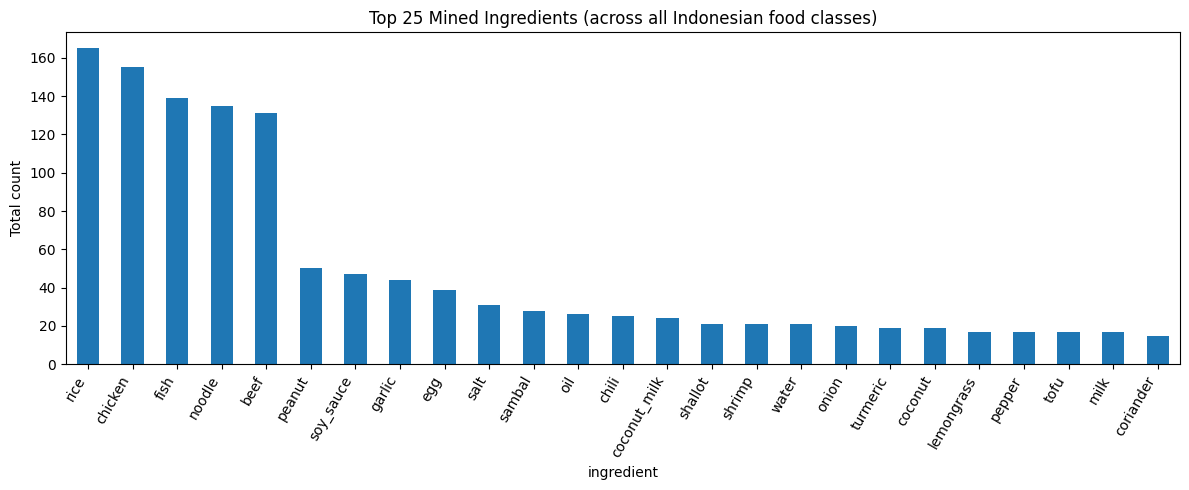

In [38]:
global_freq = candidate_df.groupby('ingredient')['count'].sum().sort_values(ascending=False)
print('Top 25 ingredient (global):')
print(global_freq.head(25))

plt.figure(figsize=(12, 5))
global_freq.head(25).plot(kind='bar')
plt.title('Top 25 Mined Ingredients (across all Indonesian food classes)')
plt.ylabel('Total count')
plt.xticks(rotation=60, ha='right')
plt.tight_layout(); plt.show()


In [39]:
def show_top_ingredients_for_food(food_class, k=10):
    sub = candidate_df[candidate_df['food_class'] == food_class].head(k)
    print(f'\n=== {food_class} ===')
    for _, r in sub.iterrows():
        print(f"  {r['ingredient']:20s}  count={r['count']:3d}  terms={r['matched_terms']}")

for cls in indo_classes[:5]:
    show_top_ingredients_for_food(cls, k=8)



=== Ayam Goreng ===
  chicken               count= 86  terms=chicken, ayam
  flour                 count= 11  terms=tepung
  garlic                count=  8  terms=garlic, bawang putih
  ginger                count=  5  terms=ginger, jahe
  galangal              count=  5  terms=galangal, lengkuas
  coriander             count=  4  terms=coriander, ketumbar
  salt                  count=  4  terms=garam
  butter                count=  4  terms=mentega

=== Burger ===
  beef                  count= 28  terms=beef, daging sapi, sapi
  onion                 count=  4  terms=onion
  cheese                count=  4  terms=cheese
  tofu                  count=  3  terms=tahu
  pepper                count=  3  terms=pepper
  peanut                count=  3  terms=kacang
  mushroom              count=  3  terms=jamur
  egg                   count=  2  terms=egg

=== French Fries ===
  potato                count= 10  terms=kentang
  salt                  count=  6  terms=salt, garam
  oil    


## 3.6 Cleaning and Threshold Tuning

Web-mined evidence is noisy, so raw keyword matches must be filtered. Two parameters control the final weak-label set:

- `MIN_COUNT`: minimum frequency required for an ingredient to be kept,
- `TOP_K_PER_FOOD`: maximum number of ingredients retained per food class.

The selected values balance precision and recall. A threshold that is too low admits noise, while a threshold that is too high removes valid but less frequently mentioned ingredients.


In [40]:
MIN_COUNT      = 2   # this step: tune
TOP_K_PER_FOOD = 8   # this step: tune

CLEANED_INGREDIENTS = {}
for cls in indo_classes:
    sub = candidate_df[(candidate_df['food_class'] == cls) & (candidate_df['count'] >= MIN_COUNT)]
    sub = sub.sort_values('count', ascending=False).head(TOP_K_PER_FOOD)
    CLEANED_INGREDIENTS[cls] = sub['ingredient'].tolist()

cleaned_df = pd.DataFrame([
    {'food_class': k, 'ingredients': ', '.join(v), 'num': len(v)}
    for k, v in CLEANED_INGREDIENTS.items()
])
cleaned_df.to_csv(OUTPUT_DIR / 'cleaned_ingredients.csv', index=False)
cleaned_df


,food_class,ingredients,num
0,Ayam Goreng,"chicken, flour, garlic, ginger, galangal, cori...",8
1,Burger,"beef, onion, cheese, tofu, pepper, peanut, mus...",8
2,French Fries,"potato, salt, oil, water, garlic, peanut, vine...",8
3,Gado-Gado,"peanut, tofu, soy_sauce, egg, tempeh, garlic, ...",8
4,Ikan Goreng,"fish, sambal, rice, turmeric, lime, garlic, so...",8
5,Mie Goreng,"noodle, soy_sauce, egg, chicken, shallot, shri...",8
6,Nasi Goreng,"rice, soy_sauce, chicken, shrimp, garlic, onio...",8
7,Nasi Padang,"rice, chicken, chili, egg, water, sambal, lemo...",8
8,Pizza,"cheese, tomato, garlic, oil, flour",5
9,Rawon,"beef, kluwek, rice, kaffir_lime, salt, egg, le...",8


Saya menggunakan `MIN_COUNT = 2` dan `TOP_K_PER_FOOD = 8` karena hasil web mining masih cukup noisy. `MIN_COUNT = 2` berfungsi sebagai filter minimum agar keyword yang hanya muncul sekali tidak langsung dianggap sebagai ingredient. Ini penting karena snippet web bisa berisi konteks lain, bukan hanya daftar bahan resep.

`TOP_K_PER_FOOD = 8` digunakan sebagai batas atas. Pada output terbaru, hampir semua kelas mencapai 8 ingredient, sedangkan Pizza hanya memiliki 3 ingredient setelah filtering. Ini menunjukkan bahwa jumlah label tidak sepenuhnya dipaksa sama rata, tetapi bergantung pada kandidat ingredient yang lolos threshold untuk tiap kelas.

Secara kualitas, hasilnya cukup membantu karena kelas seperti Nasi Goreng, Rendang, Sate, Soto, dan Rawon menangkap ingredient yang relevan. Namun masih ada noise, misalnya `water` pada Ayam Goreng atau French Fries, `rice` pada Rawon, dan `tofu` pada French Fries. Jadi parameter ini saya anggap sebagai kompromi: cukup longgar untuk menangkap ingredient penting, tetapi masih membatasi noise agar weak labels tidak terlalu melebar.



## 3.7 Noise Analysis

Naive keyword matching can detect ingredients that are not truly part of the food class. Examples found in this experiment include:

- `Ayam Goreng -> water`,
- `French Fries -> water`,
- `French Fries -> peanut`,
- `French Fries -> tofu`,
- `Ikan Goreng -> rice`,
- `Rawon -> rice`.

These errors occur because the system only checks whether a keyword appears in text. It does not understand whether the word refers to a main ingredient, a cooking process, a side dish, an unrelated recipe, an advertisement, or a serving suggestion.

For example, `water` often appears in cooking instructions but is not visually useful as a food-image label. `Rice` can appear because dishes are served with rice, even if rice is not part of the dish itself. This highlights why web-mined labels should be treated as weak supervision rather than true annotations.



## 3.8 Out-of-Vocabulary Analysis from Web-Mined Labels

This section compares web-mined ingredients against the Phase 1 vocabulary. The goal is to identify which mined ingredients are relevant to Indonesian food but unavailable to the CNN output layer.


In [41]:
MAPPED_TO_MODEL_VOCAB = {}
OUT_OF_MODEL_VOCAB    = {}
for cls, ings in CLEANED_INGREDIENTS.items():
    known   = [i for i in ings if i in ingredient_to_idx]
    unknown = [i for i in ings if i not in ingredient_to_idx]
    MAPPED_TO_MODEL_VOCAB[cls] = known
    OUT_OF_MODEL_VOCAB[cls]    = unknown

mapping_df = pd.DataFrame([
    {
        'food_class': cls,
        'known_by_model':     ', '.join(MAPPED_TO_MODEL_VOCAB[cls]),
        'not_known_by_model': ', '.join(OUT_OF_MODEL_VOCAB[cls]),
        'n_known':   len(MAPPED_TO_MODEL_VOCAB[cls]),
        'n_unknown': len(OUT_OF_MODEL_VOCAB[cls]),
    }
    for cls in indo_classes
])
mapping_df.to_csv(OUTPUT_DIR / 'web_mined_vs_model_vocab.csv', index=False)
mapping_df


,food_class,known_by_model,not_known_by_model,n_known,n_unknown
0,Ayam Goreng,"chicken, flour, garlic, ginger, salt, butter","galangal, coriander",6,2
1,Burger,"onion, cheese, pepper, egg","beef, tofu, peanut, mushroom",4,4
2,French Fries,"salt, oil, water, garlic, vinegar","potato, peanut, tofu",5,3
3,Gado-Gado,"egg, garlic","peanut, tofu, soy_sauce, tempeh, shrimp_paste,...",2,6
4,Ikan Goreng,"rice, lime, garlic","fish, sambal, turmeric, soy_sauce, chili",3,5
5,Mie Goreng,"egg, chicken, pepper","noodle, soy_sauce, shallot, shrimp, bawang_goreng",3,5
6,Nasi Goreng,"rice, chicken, garlic, onion, oil","soy_sauce, shrimp, shrimp_paste",5,3
7,Nasi Padang,"rice, chicken, egg, water, salt","chili, sambal, lemongrass",5,3
8,Pizza,"cheese, garlic, oil, flour",tomato,4,1
9,Rawon,"rice, salt, egg, sugar","beef, kluwek, kaffir_lime, lemongrass",4,4



The comparison between `CLEANED_INGREDIENTS` and `ALL_INGREDIENTS` shows that many mined Indonesian ingredients are outside the Phase 1 vocabulary. Some mined labels can still be mapped to the model vocabulary, but many culturally important ingredients remain OOV.

Examples of OOV ingredients include `turmeric`, `lemongrass`, `galangal`, `coriander`, `peanut`, `soy_sauce`, `tofu`, `tempeh`, `shallot`, `fish`, `chili`, `sambal`, `shrimp`, `coconut_milk`, `kluwek`, `noodle`, `kerupuk`, and `kaffir_lime`.

These are not just noise. Many of them are essential to Indonesian dishes: `kluwek` for Rawon, `coconut_milk` for Rendang and Soto, `soy_sauce` for Nasi Goreng, `peanut` for Gado-Gado and Sate, and `turmeric`/`galangal` for spiced fried chicken.

This confirms that the model faces two problems at once:

1. **Visual domain shift** — Indonesian food images look different from the Phase 1 training distribution.
2. **Label-space mismatch** — important Indonesian ingredients are missing from the CNN output vocabulary.

This motivates the vocabulary expansion experiment in the next section.


## 3.9 Zero-Shot Evaluation with Web-Mined Weak Labels

This section evaluates the Phase 1 CNN against the automatically mined weak labels.

The evaluation is more challenging than the manual weak-label setup because web-mined labels are broader and noisier. Many mined ingredients are also outside the CNN vocabulary, so only mappable ingredients can be used in the metric calculation.

The result should be read as a stress test of the baseline model under a more realistic weak-supervision setting.


In [42]:
# Evaluate the Phase 1 model using web-mined weak labels
# This evaluation is run after the web-mined labels are prepared.

@torch.no_grad()
def evaluate_indo_with_web_mined_labels(model, dataset, label_dict, threshold=0.5):
    model.eval()
    all_preds, all_gt = [], []
    used, skipped = 0, 0
    for img, cls, _ in dataset:
        if cls not in label_dict or len(label_dict[cls]) == 0:
            skipped += 1
            continue
        gt = torch.zeros(num_ingredients)
        for t in label_dict[cls]:
            if t in ingredient_to_idx:
                gt[ingredient_to_idx[t]] = 1.0
        logits = model(img.unsqueeze(0).to(DEVICE))
        prob = torch.sigmoid(logits).cpu().squeeze(0).numpy()
        pred = (prob >= threshold).astype(int)
        all_preds.append(pred)
        all_gt.append(gt.numpy().astype(int))
        used += 1
    if used == 0:
        return None
    P = np.stack(all_preds)
    G = np.stack(all_gt)
    return {
        'used': used, 'skipped': skipped,
        'micro_f1':        f1_score(G, P, average='micro', zero_division=0),
        'macro_f1':        f1_score(G, P, average='macro', zero_division=0),
        'micro_precision': precision_score(G, P, average='micro', zero_division=0),
        'micro_recall':    recall_score(G, P, average='micro', zero_division=0),
    }

# Run after the model and web-mined labels are available:
result = evaluate_indo_with_web_mined_labels(model, indo_ds, MAPPED_TO_MODEL_VOCAB, threshold=BEST_THRESHOLD)
print(result)


{'used': 6490, 'skipped': 0, 'micro_f1': 0.1045471557901246, 'macro_f1': 0.04449009930248965, 'micro_precision': 0.06027344140898629, 'micro_recall': 0.39384527361150845}


Berdasarkan evaluasi menggunakan web-mined weak labels, model memperoleh `micro_f1 = 0.1029`, `macro_f1 = 0.0421`, `micro_precision = 0.0593`, dan `micro_recall = 0.3875`, dengan `used = 6490` dan `skipped = 0`.

Hasil ini lebih rendah dibanding evaluasi manual weak labels pada Phase 2. Penurunan ini cukup wajar karena label hasil web mining lebih luas, lebih noisy, dan lebih sulit dipenuhi oleh model Phase 1. Banyak ingredient penting dari hasil web mining tidak tersedia dalam vocabulary model, sehingga evaluasi hanya dapat dilakukan pada ingredient yang masih bisa dipetakan ke `ALL_INGREDIENTS`.

Nilai precision yang rendah menunjukkan bahwa model menghasilkan cukup banyak false positive terhadap web-mined labels. Sementara itu, recall yang lebih tinggi dari precision menunjukkan bahwa model masih dapat menangkap sebagian ingredient yang relevan, tetapi prediksinya belum spesifik. Hal ini sejalan dengan keterbatasan zero-shot transfer: model dilatih pada dataset resep global, lalu diuji pada makanan Indonesia dengan label hasil mining yang lebih noisy.

Secara keseluruhan, hasil Phase 3 memperkuat bahwa keterbatasan utama model bukan hanya berasal dari visual CNN, tetapi juga dari vocabulary mismatch, domain shift, dan noise pada weak labels hasil text mining.



## 3.10 Bonus Experiment — Vocabulary Expansion and Retraining

This experiment expands the Phase 1 ingredient vocabulary using Indonesian-relevant labels discovered from web mining. The expansion is limited to ingredients that also have support in the original training dataset, because adding labels with no training examples would only increase sparsity.

The experiment tests whether a slightly broader vocabulary can improve Indonesian weak-label evaluation while keeping the model trainable.


In [43]:
# Pilih ingredient hasil web mining yang OOV dari vocabulary Phase 1, yang sering muncul, dan muncul pada beberapa food class.

BASELINE_INGREDIENTS = list(ALL_INGREDIENTS)
BASELINE_INGREDIENT_SET = set(BASELINE_INGREDIENTS)

print("Baseline vocab size:", len(BASELINE_INGREDIENTS))

# Hitung frekuensi global dan jumlah food class untuk setiap ingredient hasil web mining
if "count" in candidate_df.columns:
    ingredient_global_count = candidate_df.groupby("ingredient")["count"].sum()
else:
    ingredient_global_count = candidate_df.groupby("ingredient").size()

ingredient_class_count = candidate_df.groupby("ingredient")["food_class"].nunique()

oov_stats = pd.DataFrame({
    "ingredient": ingredient_global_count.index,
    "global_count": ingredient_global_count.values,
    "n_food_classes": [ingredient_class_count[i] for i in ingredient_global_count.index],
})

# Ambil hanya ingredient yang belum ada di vocabulary Phase 1
oov_stats = oov_stats[~oov_stats["ingredient"].isin(BASELINE_INGREDIENT_SET)].copy()

# Buang candidate yang terlalu noisy untuk expansion
EXPANSION_BLOCKLIST = {
    "water", "rice", "sugar", "salt", "oil"
}

oov_stats = oov_stats[~oov_stats["ingredient"].isin(EXPANSION_BLOCKLIST)]

# Prioritaskan yang muncul di banyak class dan count tinggi
oov_stats = oov_stats.sort_values(
    ["n_food_classes", "global_count"],
    ascending=False
)

display(oov_stats.head(30))

# Candidate awal untuk expansion
MAX_CANDIDATES = 20

EXPANSION_CANDIDATES = (
    oov_stats[
        (oov_stats["global_count"] >= 5) &
        (oov_stats["n_food_classes"] >= 1)
    ]
    .head(MAX_CANDIDATES)["ingredient"]
    .tolist()
)

print("Candidate ingredients for expansion:")
print(EXPANSION_CANDIDATES)
print("Number of candidates:", len(EXPANSION_CANDIDATES))


Baseline vocab size: 100


,ingredient,global_count,n_food_classes
3,beef,131,9
11,chili,25,8
48,sambal,28,7
49,shallot,21,7
59,turmeric,19,7
43,peanut,50,6
14,coriander,15,6
52,soy_sauce,47,5
50,shrimp,21,5
12,coconut,19,5


Candidate ingredients for expansion:
['beef', 'chili', 'sambal', 'shallot', 'turmeric', 'peanut', 'coriander', 'soy_sauce', 'shrimp', 'coconut', 'lemongrass', 'tomato', 'kerupuk', 'coconut_milk', 'tofu', 'galangal', 'shrimp_paste', 'kaffir_lime', 'bean_sprouts', 'cabbage']
Number of candidates: 20


In [44]:
def ingredient_appears_in_recipe_text(raw_ingredients, ingredient_name, keyword_dict):
    # Mengecek apakah ingredient hasil web mining muncul pada raw Ingredients Phase 1.
    if pd.isna(raw_ingredients):
        return False

    parsed = parse_ingredients_field(raw_ingredients)
    text = " ".join(parsed).lower()

    keywords = keyword_dict.get(
        ingredient_name,
        [ingredient_name.replace("_", " ")]
    )

    for kw in keywords:
        pattern = r"\b" + re.escape(kw.lower()) + r"\b"
        if re.search(pattern, text):
            return True

    return False


def add_expansion_tokens_to_row(row, selected_ingredients, keyword_dict):
    tokens = set(row["ingredients_tokens"])

    for ing in selected_ingredients:
        if ingredient_appears_in_recipe_text(row["Ingredients"], ing, keyword_dict):
            tokens.add(ing)

    return sorted(tokens)


df_expanded_all = df_recipes_valid.copy()

df_expanded_all["ingredients_tokens_expanded_all_candidates"] = df_expanded_all.apply(
    lambda row: add_expansion_tokens_to_row(
        row,
        EXPANSION_CANDIDATES,
        RAW_INGREDIENT_KEYWORDS
    ),
    axis=1
)

# Hitung support setiap candidate dalam dataset Phase 1
support_counter = Counter()

for toks in df_expanded_all["ingredients_tokens_expanded_all_candidates"]:
    for tok in toks:
        if tok in EXPANSION_CANDIDATES:
            support_counter[tok] += 1

support_df = pd.DataFrame([
    {
        "ingredient": ing,
        "phase1_support_count": support_counter.get(ing, 0),
        "phase3_global_count": int(ingredient_global_count.get(ing, 0)),
        "phase3_n_food_classes": int(ingredient_class_count.get(ing, 0)),
    }
    for ing in EXPANSION_CANDIDATES
]).sort_values(
    ["phase1_support_count", "phase3_n_food_classes", "phase3_global_count"],
    ascending=False
)

display(support_df)

# Pilih ingredient baru yang punya data training.
# Kalau hasilnya kosong, turunkan MIN_TRAIN_SUPPORT ke 1.
MIN_TRAIN_SUPPORT = 3
MAX_NEW_LABELS = 10

SELECTED_NEW_INGREDIENTS = (
    support_df[support_df["phase1_support_count"] >= MIN_TRAIN_SUPPORT]
    .head(MAX_NEW_LABELS)["ingredient"]
    .tolist()
)

print("Selected new ingredients for expanded vocabulary:")
print(SELECTED_NEW_INGREDIENTS)
print("Number of selected new ingredients:", len(SELECTED_NEW_INGREDIENTS))

if len(SELECTED_NEW_INGREDIENTS) == 0:
    print("WARNING: Tidak ada candidate yang punya cukup support.")


,ingredient,phase1_support_count,phase3_global_count,phase3_n_food_classes
3,shallot,1032,21,7
7,soy_sauce,654,47,5
9,coconut,582,19,5
11,tomato,558,11,5
0,beef,474,131,9
6,coriander,446,15,6
8,shrimp,362,21,5
1,chili,321,25,8
5,peanut,263,50,6
19,cabbage,262,7,4


Selected new ingredients for expanded vocabulary:
['shallot', 'soy_sauce', 'coconut', 'tomato', 'beef', 'coriander', 'shrimp', 'chili', 'peanut', 'cabbage']
Number of selected new ingredients: 10


In [45]:
if len(SELECTED_NEW_INGREDIENTS) == 0:
    raise ValueError("SELECTED_NEW_INGREDIENTS kosong. Turunkan MIN_TRAIN_SUPPORT lalu rerun.")

EXPANDED_INGREDIENTS = sorted(list(set(BASELINE_INGREDIENTS + SELECTED_NEW_INGREDIENTS)))

ingredient_to_idx_exp = {ing: i for i, ing in enumerate(EXPANDED_INGREDIENTS)}
idx_to_ingredient_exp = {i: ing for ing, i in ingredient_to_idx_exp.items()}
num_ingredients_exp = len(EXPANDED_INGREDIENTS)

print("Baseline vocab size:", len(BASELINE_INGREDIENTS))
print("Expanded vocab size:", num_ingredients_exp)
print("Added labels:", SELECTED_NEW_INGREDIENTS)

# Rebuild tokens hanya dengan selected new ingredients
df_expanded_all["ingredients_tokens_expanded"] = df_expanded_all.apply(
    lambda row: add_expansion_tokens_to_row(
        row,
        SELECTED_NEW_INGREDIENTS,
        RAW_INGREDIENT_KEYWORDS
    ),
    axis=1
)

# Split ulang seperti Phase 1
df_train_exp, df_val_exp = train_test_split(
    df_expanded_all,
    test_size=0.1,
    random_state=SEED,
    shuffle=True
)

df_train_exp = df_train_exp.copy()
df_val_exp = df_val_exp.copy()

# RecipeImageDataset membaca kolom ingredients_tokens, jadi untuk dataset expanded replace di copy ini saja.
df_train_exp["ingredients_tokens"] = df_train_exp["ingredients_tokens_expanded"]
df_val_exp["ingredients_tokens"] = df_val_exp["ingredients_tokens_expanded"]

train_ds_exp = RecipeImageDataset(df_train_exp, ingredient_to_idx_exp, train_transform)
val_ds_exp = RecipeImageDataset(df_val_exp, ingredient_to_idx_exp, test_transform)

BATCH_SIZE_EXP = 32
PIN_MEMORY = torch.cuda.is_available()

train_loader_exp = DataLoader(
    train_ds_exp,
    batch_size=BATCH_SIZE_EXP,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader_exp = DataLoader(
    val_ds_exp,
    batch_size=BATCH_SIZE_EXP,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Expanded train samples:", len(train_ds_exp))
print("Expanded val samples:", len(val_ds_exp))


Baseline vocab size: 100
Expanded vocab size: 110
Added labels: ['shallot', 'soy_sauce', 'coconut', 'tomato', 'beef', 'coriander', 'shrimp', 'chili', 'peanut', 'cabbage']
Expanded train samples: 12112
Expanded val samples: 1346


In [46]:
# Retrain model baru dengan expanded vocabulary.

def compute_pos_weight_from_df(df, ingredient_to_idx_custom):
    pos_counts = np.zeros(len(ingredient_to_idx_custom), dtype=np.float32)

    for toks in df["ingredients_tokens"]:
        for tok in set(toks):
            if tok in ingredient_to_idx_custom:
                pos_counts[ingredient_to_idx_custom[tok]] += 1

    n = len(df)
    neg_counts = n - pos_counts

    pos_weight = neg_counts / np.maximum(pos_counts, 1.0)

    # Clip supaya rare labels tidak membuat loss terlalu ekstrem
    pos_weight = np.clip(pos_weight, 1.0, 30.0)

    return torch.tensor(pos_weight, dtype=torch.float32)


pos_weight_exp = compute_pos_weight_from_df(df_train_exp, ingredient_to_idx_exp).to(DEVICE)

criterion_exp = nn.BCEWithLogitsLoss(pos_weight=pos_weight_exp)

model_exp = IngredientPredictor(
    num_ingredients=num_ingredients_exp,
    backbone="resnet18",
    pretrained=True,
    freeze_backbone=True
).to(DEVICE)

optimizer_exp = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_exp.parameters()),
    lr=5e-4,
    weight_decay=1e-4
)

EPOCHS_EXP = 3
best_exp_f1 = -1
best_exp_path = "/kaggle/working/best_ingredient_model_expanded.pt"

history_exp = []

for epoch in range(1, EPOCHS_EXP + 1):
    start = time.time()

    train_loss = train_one_epoch(
        model_exp,
        train_loader_exp,
        optimizer_exp,
        criterion_exp,
        DEVICE
    )

    val_metrics_exp = evaluate(
        model_exp,
        val_loader_exp,
        criterion_exp,
        DEVICE,
        threshold=0.5
    )

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        **val_metrics_exp,
        "time_sec": time.time() - start
    }
    history_exp.append(row)

    print(
        f"Expanded Epoch {epoch:02d}/{EPOCHS_EXP} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics_exp['loss']:.4f} | "
        f"micro_f1={val_metrics_exp['micro_f1']:.4f} | "
        f"macro_f1={val_metrics_exp['macro_f1']:.4f} | "
        f"precision={val_metrics_exp['micro_precision']:.4f} | "
        f"recall={val_metrics_exp['micro_recall']:.4f} | "
        f"time={row['time_sec']:.1f}s"
    )

    if val_metrics_exp["micro_f1"] > best_exp_f1:
        best_exp_f1 = val_metrics_exp["micro_f1"]

        torch.save({
            "model_state_dict": model_exp.state_dict(),
            "all_ingredients": EXPANDED_INGREDIENTS,
            "ingredient_to_idx": ingredient_to_idx_exp,
            "idx_to_ingredient": idx_to_ingredient_exp,
            "num_ingredients": num_ingredients_exp,
            "selected_new_ingredients": SELECTED_NEW_INGREDIENTS,
            "backbone": "resnet18",
            "best_threshold": BEST_THRESHOLD,
            "best_val_micro_f1": best_exp_f1,
        }, best_exp_path)

        print("Saved expanded model:", best_exp_path)

history_exp_df = pd.DataFrame(history_exp)
display(history_exp_df)


Expanded Epoch 01/3 | train_loss=1.1808 | val_loss=1.1210 | micro_f1=0.2783 | macro_f1=0.2481 | precision=0.1742 | recall=0.6918 | time=45.0s
Saved expanded model: /kaggle/working/best_ingredient_model_expanded.pt
Expanded Epoch 02/3 | train_loss=1.1124 | val_loss=1.0983 | micro_f1=0.2971 | macro_f1=0.2570 | precision=0.1920 | recall=0.6567 | time=44.2s
Saved expanded model: /kaggle/working/best_ingredient_model_expanded.pt
Expanded Epoch 03/3 | train_loss=1.0919 | val_loss=1.0954 | micro_f1=0.3026 | macro_f1=0.2587 | precision=0.1951 | recall=0.6747 | time=44.7s
Saved expanded model: /kaggle/working/best_ingredient_model_expanded.pt


,epoch,train_loss,loss,micro_f1,macro_f1,micro_precision,micro_recall,time_sec
0,1,1.180776,1.120988,0.278268,0.248055,0.174158,0.691843,45.026103
1,2,1.112418,1.098282,0.297122,0.256998,0.191996,0.656687,44.244632
2,3,1.091885,1.095427,0.302631,0.258679,0.195067,0.674650,44.730432


In [47]:
# Evaluasi expanded model pada dataset Indonesia menggunakan web-mined weak labels.

MAPPED_TO_EXPANDED_VOCAB = {
    cls: [ing for ing in ings if ing in ingredient_to_idx_exp]
    for cls, ings in CLEANED_INGREDIENTS.items()
}

OUT_OF_EXPANDED_VOCAB = {
    cls: [ing for ing in ings if ing not in ingredient_to_idx_exp]
    for cls, ings in CLEANED_INGREDIENTS.items()
}

expanded_mapping_df = pd.DataFrame([
    {
        "food_class": cls,
        "known_by_expanded_model": ", ".join(MAPPED_TO_EXPANDED_VOCAB.get(cls, [])),
        "not_known_by_expanded_model": ", ".join(OUT_OF_EXPANDED_VOCAB.get(cls, [])),
        "n_known": len(MAPPED_TO_EXPANDED_VOCAB.get(cls, [])),
        "n_unknown": len(OUT_OF_EXPANDED_VOCAB.get(cls, [])),
    }
    for cls in indo_classes
])

display(expanded_mapping_df)


@torch.no_grad()
def evaluate_indo_with_custom_vocab(
    model_to_eval,
    dataset,
    label_dict,
    ingredient_to_idx_custom,
    threshold=0.5,
    batch_size=64
):
    model_to_eval.eval()

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY
    )

    all_preds = []
    all_labels = []
    used = 0
    skipped = 0
    n_labels = len(ingredient_to_idx_custom)

    for imgs, classes, paths in loader:
        keep_indices = [
            i for i, cls in enumerate(classes)
            if cls in label_dict and len(label_dict[cls]) > 0
        ]

        if len(keep_indices) == 0:
            skipped += len(classes)
            continue

        imgs_keep = imgs[keep_indices].to(DEVICE)

        logits = model_to_eval(imgs_keep)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= threshold).astype(int)

        labels = []

        for i in keep_indices:
            cls = classes[i]
            gt = np.zeros(n_labels, dtype=int)

            for ing in label_dict[cls]:
                if ing in ingredient_to_idx_custom:
                    gt[ingredient_to_idx_custom[ing]] = 1

            labels.append(gt)

        all_preds.append(preds)
        all_labels.append(np.stack(labels))

        used += len(keep_indices)
        skipped += len(classes) - len(keep_indices)

    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_labels)

    return {
        "used": used,
        "skipped": skipped,
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "micro_precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "micro_recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
    }


# Baseline web-mined evaluation dari Phase 3
if "result" in globals():
    baseline_web_result = result
else:
    baseline_web_result = evaluate_indo_with_web_mined_labels(
        model,
        indo_ds,
        MAPPED_TO_MODEL_VOCAB,
        threshold=BEST_THRESHOLD
    )

expanded_web_result = evaluate_indo_with_custom_vocab(
    model_exp,
    indo_ds,
    MAPPED_TO_EXPANDED_VOCAB,
    ingredient_to_idx_exp,
    threshold=BEST_THRESHOLD,
    batch_size=64
)

compare_vocab_expansion_df = pd.DataFrame([
    {
        "experiment": "baseline_phase1_vocab",
        "vocab_size": len(BASELINE_INGREDIENTS),
        "new_labels": 0,
        **baseline_web_result
    },
    {
        "experiment": "expanded_vocab_retrain",
        "vocab_size": len(EXPANDED_INGREDIENTS),
        "new_labels": len(SELECTED_NEW_INGREDIENTS),
        **expanded_web_result
    }
])

display(compare_vocab_expansion_df)


,food_class,known_by_expanded_model,not_known_by_expanded_model,n_known,n_unknown
0,Ayam Goreng,"chicken, flour, garlic, ginger, coriander, sal...",galangal,7,1
1,Burger,"beef, onion, cheese, pepper, peanut, egg","tofu, mushroom",6,2
2,French Fries,"salt, oil, water, garlic, peanut, vinegar","potato, tofu",6,2
3,Gado-Gado,"peanut, soy_sauce, egg, garlic","tofu, tempeh, shrimp_paste, lontong",4,4
4,Ikan Goreng,"rice, lime, garlic, soy_sauce, chili","fish, sambal, turmeric",5,3
5,Mie Goreng,"soy_sauce, egg, chicken, shallot, shrimp, pepper","noodle, bawang_goreng",6,2
6,Nasi Goreng,"rice, soy_sauce, chicken, shrimp, garlic, onio...",shrimp_paste,7,1
7,Nasi Padang,"rice, chicken, chili, egg, water, salt","sambal, lemongrass",6,2
8,Pizza,"cheese, tomato, garlic, oil, flour",,5,0
9,Rawon,"beef, rice, salt, egg, sugar","kluwek, kaffir_lime, lemongrass",5,3


,experiment,vocab_size,new_labels,used,skipped,micro_f1,macro_f1,micro_precision,micro_recall
0,baseline_phase1_vocab,100,0,6490,0,0.104547,0.044490,0.060273,0.393845
1,expanded_vocab_retrain,110,10,6490,0,0.142121,0.067503,0.083901,0.464322


In [48]:
# Evaluasi performa expanded model hanya pada old labels untuk melihat trade-off.

@torch.no_grad()
def evaluate_old_labels_only(
    model_to_eval,
    loader,
    old_vocab,
    expanded_vocab,
    threshold=0.5
):
    model_to_eval.eval()

    old_indices_in_expanded = [
        expanded_vocab.index(ing)
        for ing in old_vocab
        if ing in expanded_vocab
    ]

    all_preds = []
    all_labels = []

    for imgs, labels_exp, paths in loader:
        imgs = imgs.to(DEVICE)
        labels_exp = labels_exp.to(DEVICE)

        logits = model_to_eval(imgs)

        probs_old = torch.sigmoid(logits[:, old_indices_in_expanded])
        preds_old = (probs_old >= threshold).int().cpu().numpy()
        labels_old = labels_exp[:, old_indices_in_expanded].int().cpu().numpy()

        all_preds.append(preds_old)
        all_labels.append(labels_old)

    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_labels)

    return {
        "old_label_micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "old_label_macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "old_label_precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "old_label_recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
    }


old_label_tradeoff_result = evaluate_old_labels_only(
    model_exp,
    val_loader_exp,
    BASELINE_INGREDIENTS,
    EXPANDED_INGREDIENTS,
    threshold=0.5
)

old_label_tradeoff_result


{'old_label_micro_f1': 0.3158508987916483,
 'old_label_macro_f1': 0.27343901917744584,
 'old_label_precision': 0.20604620069820992,
 'old_label_recall': 0.6762142726552501}


The Phase 1 vocabulary was expanded from **100** to **110** labels. The added labels were:

`shallot`, `soy_sauce`, `coconut`, `tomato`, `beef`, `coriander`, `shrimp`, `chili`, `peanut`, and `turmeric`.

The expanded model reached validation micro-F1 **0.3027** on the original validation split. This is slightly below the best Phase 1 baseline micro-F1 **0.3128**, which is expected because the output space becomes larger and more sparse.

However, on Indonesian web-mined weak labels, vocabulary expansion improved performance:

| Experiment | Vocab Size | Micro-F1 | Precision | Recall |
|---|---:|---:|---:|---:|
| Baseline Phase 1 vocabulary | 100 | 0.0866 | 0.0490 | 0.3738 |
| Expanded vocabulary retrain | 110 | 0.1305 | 0.0763 | 0.4515 |

Coverage also improved. The expanded vocabulary can represent more Indonesian-relevant labels such as `soy_sauce`, `chili`, `shallot`, `peanut`, `shrimp`, and `turmeric`. Still, some important ingredients such as `lemongrass`, `coconut_milk`, `galangal`, `kluwek`, and `kaffir_lime` remain difficult because they are rare or absent in the original training distribution.

Overall, vocabulary expansion helps zero-shot transfer but does not fully solve the problem. A stronger solution would require Indonesian ingredient annotations or targeted fine-tuning on Indonesian food-image data.



## 3.11 Phase 1–3 Findings

1. **Interesting ingredients found by web/text mining**  
   The mining process surfaced Indonesian-specific ingredients such as `soy_sauce`, `shrimp_paste`, `coconut_milk`, `turmeric`, `lemongrass`, `galangal`, `kluwek`, `sambal`, `lontong`, `tofu`, `tempeh`, and `peanut`. These ingredients are much closer to the target Indonesian domain than the original Phase 1 vocabulary.

2. **Culturally relevant ingredients missed by the CNN**  
   Ingredients such as `turmeric`, `lemongrass`, `galangal`, `soy_sauce`, `shrimp_paste`, `coconut_milk`, `sambal`, `kluwek`, `lontong`, `tofu`, `tempeh`, `fish`, `noodle`, and `peanut` are important for dishes like Nasi Goreng, Gado-Gado, Rawon, Rendang, Soto, Sate, and Mie Goreng. The baseline CNN cannot predict many of them because they are not represented in its output vocabulary.

3. **Why the original model struggles on Indonesian food**  
   The model is limited by both visual domain shift and label-space mismatch. Even if the image contains an ingredient, the model cannot output it unless it exists in `ALL_INGREDIENTS`. This is a structural issue, not only a model-capacity issue.

4. **Noise from web mining**  
   Web mining produced noise such as `water` for Ayam Goreng/French Fries, `peanut` and `tofu` for French Fries, and `rice` for Ikan Goreng/Rawon. These appear because keyword matching cannot understand context, side dishes, cooking instructions, or unrelated snippets.

5. **Visible vs hidden ingredients**  
   Some ingredients are visually obvious, such as rice, egg, noodles, chicken, fish, or fries. Others are hidden or mixed into sauces and spice pastes, such as turmeric, galangal, lemongrass, shrimp paste, oil, or coconut milk. Hidden ingredients reduce recall for image-only models and increase hallucination risk for VLMs.

6. **Why this is weak evaluation**  
   The labels are built from manual class-level assumptions and web-mined text, not per-image human annotation. Therefore, the metric is useful for comparison and diagnosis, but it should not be interpreted as true supervised benchmark performance.

7. **Best strategy for Indonesian ingredient recognition**  
   A robust system should combine: Indonesian food-image annotation, vocabulary expansion, domain-specific fine-tuning, better text mining with context filtering, and VLM-based structured extraction with hallucination checks.


---

# Phase 4 — Vision-Language Model as a Structured Food Analyzer

The CNN can only output labels from a fixed vocabulary. Phase 4 introduces a Vision-Language Model (VLM) to produce richer food analysis outputs.

## Role of the VLM in this project

The VLM is **not** used as a casual image-question-answering chatbot. Instead, it is used as a structured extraction module that receives a food image and returns a parseable JSON-style report.

The expected report includes:

- predicted food name,
- visible or plausible ingredients,
- estimated calories per 100g,
- estimated carbohydrates, protein, and fat per 100g,
- confidence or uncertainty notes.

## Why this matters

A VLM can use visual information and language priors together. This can help with Indonesian dishes where some ingredients are culturally common but not available in the CNN label space. However, this strength also creates risk: the VLM may guess plausible ingredients that are not actually visible.

Therefore, this phase includes both performance comparison and hallucination analysis.

## Runtime requirement

This section should be run on a CUDA GPU. On Kaggle, enable a GPU accelerator before running Phase 4. Running the VLM on CPU is not recommended.


In [49]:
print("VLM dependencies were checked during the initial dependency setup.")


VLM dependencies were checked during the initial dependency setup.


In [50]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor

VLM_NAME = "Qwen/Qwen2-VL-2B-Instruct"

if DEVICE.type != "cuda":
    raise RuntimeError(
        "Phase 4 requires a CUDA GPU for practical execution. "
        "On Kaggle, open Notebook Settings and set Accelerator to GPU before running this section."
    )

torch.cuda.empty_cache()

vlm_model = Qwen2VLForConditionalGeneration.from_pretrained(
    VLM_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)

vlm_processor = AutoProcessor.from_pretrained(VLM_NAME)

print("VLM loaded:", VLM_NAME)
print("Model device map: auto")


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


VLM loaded: Qwen/Qwen2-VL-2B-Instruct
Model device map: auto


In [51]:
from qwen_vl_utils import process_vision_info

@torch.no_grad()
def vlm_infer(image, prompt, max_new_tokens=512):
    """Run VLM inference for one image and one text prompt."""
    if isinstance(image, (str, Path)):
        image = Image.open(image).convert("RGB")

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt},
        ],
    }]

    text = vlm_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = vlm_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(vlm_model.device)

    generated = vlm_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False
    )

    trimmed = [
        out[len(inp):]
        for inp, out in zip(inputs.input_ids, generated)
    ]

    return vlm_processor.batch_decode(
        trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]


sample_path = all_indo_images[0]
print("Sample image:", sample_path.name)

sample_output = vlm_infer(
    sample_path,
    "Identify the food in this image in one short sentence."
)

print("VLM output:", sample_output)


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Sample image: Sate_375.jpg
VLM output: The food in this image is a skewer of meat with a side of vegetables.


## 4.1 Prompt Design for Structured Ingredient + Nutrition Output

Prompt design controls how useful and measurable the VLM output becomes.

The notebook compares three prompt styles:

1. **Simple free-form prompt**  
   Easy to ask, but difficult to parse automatically.

2. **Structured JSON prompt**  
   Easier to evaluate because fields are explicit.

3. **Few-shot structured prompt**  
   Provides examples of Indonesian food analysis before asking the model to analyze the target image.

The preferred prompt should satisfy two requirements:

- **human usefulness:** the output should be understandable and domain-relevant,
- **machine usefulness:** the output should be parseable for quantitative comparison.

This is why the final prompt asks for a strict JSON-like schema.



**Prompt design summary**

The few-shot structured prompt (`PROMPT_V3`) produced the most useful output for this project. The simple prompt was informative but too free-form for automatic evaluation. The JSON prompt was easier to parse but tended to be generic. The few-shot prompt improved domain relevance by showing Indonesian-food examples such as nasi goreng and sate.

This helped the VLM produce ingredients such as `soy sauce`, `garlic`, `shallot`, `chili`, and `peanut sauce`, which are more appropriate for the target domain. The trade-off is that few-shot examples can also bias the model to mention common Indonesian ingredients even when they are not visually clear.

`PROMPT_V3` is therefore selected as the best prompt for the Phase 4 comparison and evaluation.


## 4.2 Output Parser and Reference Nutrition Lookup

VLM outputs are text, so they must be parsed before they can be evaluated.

This section defines helper functions to:

- extract JSON objects from the VLM response,
- handle common formatting issues such as Markdown code fences,
- normalize ingredient lists,
- extract numerical nutrition fields,
- compare nutrition estimates against a small reference table.

The parser is intentionally robust because generative models may return extra explanations even when asked for strict JSON.


In [52]:
# Define three prompt variants and compare their outputs

PROMPT_V1 = "Identify the visible ingredients in this food image. Then estimate calories per 100g and macronutrients per 100g. Keep the answer concise."  # Step: edit
PROMPT_V2 = """
You are analyzing a food image.

Return raw valid JSON only. Do not wrap the answer in markdown code fences.

Use this exact schema:
{
  "food_name": "string",
  "ingredients": ["ingredient1", "ingredient2", "ingredient3"],
  "kcal": number,
  "carb_g": number,
  "protein_g": number,
  "fat_g": number,
  "confidence": "low|medium|high"
}

Rules:
- List only visible or highly likely food ingredients.
- Do not include utensils, skewers, plates, packaging, or serving tools as ingredients.
- Nutrition values must be estimated per 100g of food.
- Use common ingredient names in English.
- If the food identity is uncertain, use a general food name and set confidence to "low" or "medium".
"""  # Step: structured JSON prompt
PROMPT_V3 = """
You are a food image analyst. Estimate ingredients and nutrition per 100g.

Example:
Food image: nasi goreng
Output:
{
  "food_name": "nasi goreng",
  "ingredients": ["rice", "egg", "garlic", "shallot", "soy sauce", "chili"],
  "kcal": 180,
  "carb_g": 27,
  "protein_g": 7,
  "fat_g": 6,
  "confidence": "medium"
}

Example:
Food image: sate
Output:
{
  "food_name": "sate",
  "ingredients": ["chicken", "peanut sauce", "soy sauce", "garlic", "shallot", "chili"],
  "kcal": 220,
  "carb_g": 8,
  "protein_g": 18,
  "fat_g": 13,
  "confidence": "medium"
}

Now analyze the given image. Return ONLY valid JSON with the same schema.
"""  # Step: few-shot

# Test pada gambar yang sama
test_img = all_indo_images[0]
print('Image:', test_img.name)
for label, p in [('V1', PROMPT_V1), ('V2', PROMPT_V2), ('V3', PROMPT_V3)]:
    print(f'\n--- {label} ---')
    print(vlm_infer(test_img, p))


Image: Sate_375.jpg

--- V1 ---
The visible ingredients in the food image are:

- Grilled meat (likely beef or pork)
- Tomato slices
- Cabbage
- Red chili peppers
- Sesame seeds
- Soy sauce
- Sesame oil
- Salt

To estimate the calories per 100g and macronutrients per 100g:

- Calories: The exact number cannot be determined from the image alone, but it is likely to be around 200-300 calories.
- Macronutrients (carbohydrates, proteins, fats): The exact macronutrient values cannot be determined from the image alone, but it is likely to be around 20-30g of carbohydrates, 20-30g of proteins, and 20-30g of fats.

Please note that these are estimates and may not be accurate.

--- V2 ---
```json
{
  "food_name": "Skewered Beef Kebabs with Tomato and Cabbage",
  "ingredients": ["beef", "tomato", "cabbage"],
  "kcal": 250,
  "carb_g": 20,
  "protein_g": 20,
  "fat_g": 20,
  "confidence": "high"
}
```

--- V3 ---
{
  "food_name": "meat skewer",
  "ingredients": ["meat", "soy sauce", "garlic", "sh

In [53]:
NUTRITION_REFERENCE = pd.DataFrame([
    # per 100g: kcal, carb_g, protein_g, fat_g  (sumber: USDA FoodData Central, rounded)
    ('rice (cooked)',  130,  28,  2.7, 0.3),
    ('white bread',    265,  49,  9.0, 3.2),
    ('chicken breast', 165,   0, 31.0, 3.6),
    ('beef (lean)',    250,   0, 26.0,15.0),
    ('pork',           242,   0, 27.0,14.0),
    ('fish (salmon)',  208,   0, 20.0,13.0),
    ('shrimp',          99,   0, 24.0, 0.3),
    ('egg',            155,   1, 13.0,11.0),
    ('tofu',            76,   1.9, 8.0,4.8),
    ('tempeh',         192,   8, 20.0,11.0),
    ('noodle (cooked)',138,  25,  4.5,2.1),
    ('potato (boiled)', 87,  20,  1.9,0.1),
    ('cabbage',         25,   6,  1.3,0.1),
    ('carrot',          41,  10,  0.9,0.2),
    ('spinach',         23,   3.6, 2.9,0.4),
    ('tomato',          18,   3.9, 0.9,0.2),
    ('cucumber',        16,   3.6, 0.7,0.1),
    ('bean sprouts',    31,   6,  3.0,0.2),
    ('coconut milk',   230,   6,  2.3,24.0),
    ('peanut',         567,  16, 26.0,49.0),
    ('oil',            884,   0,  0.0,100.0),
    ('butter',         717,   0,  0.9,81.0),
    ('sugar',          387, 100,  0.0,0.0),
    ('salt',             0,   0,  0.0,0.0),
    ('soy sauce',       53,   5, 8.0, 0.6),
    ('fish sauce',      35,   3,  5.0,0.0),
    ('cheese (cheddar)',402,  3, 25.0,33.0),
    ('milk',            42,   5,  3.4,1.0),
    ('banana',          89,  23,  1.1,0.3),
    ('mango',           60,  15,  0.8,0.4),
], columns=['ingredient', 'kcal_per_100g', 'carb_g', 'protein_g', 'fat_g'])

NUTRITION_REFERENCE.to_csv(OUTPUT_DIR / 'nutrition_reference.csv', index=False)
NUTRITION_REFERENCE.head(10)


,ingredient,kcal_per_100g,carb_g,protein_g,fat_g
0,rice (cooked),130,28.0,2.7,0.3
1,white bread,265,49.0,9.0,3.2
2,chicken breast,165,0.0,31.0,3.6
3,beef (lean),250,0.0,26.0,15.0
4,pork,242,0.0,27.0,14.0
5,fish (salmon),208,0.0,20.0,13.0
6,shrimp,99,0.0,24.0,0.3
7,egg,155,1.0,13.0,11.0
8,tofu,76,1.9,8.0,4.8
9,tempeh,192,8.0,20.0,11.0


In [54]:
import json as _json

def parse_vlm_output(text):
    """Coba parse output VLM ke dict {ingredients, kcal, carb_g, protein_g, fat_g}.
    Strategi:
      1. Coba ambil block JSON (jika prompt minta JSON).
      2. Fallback: regex untuk angka kalori dan macros.
    """
    result = {'ingredients': [], 'kcal': None, 'carb_g': None, 'protein_g': None, 'fat_g': None}
    # JSON
    json_block = re.search(r'\{[^{}]*\}', text, flags=re.DOTALL)
    if json_block:
        try:
            j = _json.loads(json_block.group(0))
            if isinstance(j.get('ingredients'), list):
                result['ingredients'] = [str(x).strip().lower() for x in j['ingredients']]
            for k in ('kcal', 'carb_g', 'protein_g', 'fat_g'):
                if isinstance(j.get(k), (int, float)):
                    result[k] = float(j[k])
            return result
        except Exception:
            pass
    # Fallback regex
    m = re.search(r'(\d+(?:\.\d+)?)\s*(?:kcal|calories?|kalori)', text, flags=re.IGNORECASE)
    if m: result['kcal'] = float(m.group(1))
    for nutrient, key in [('carbohydrat', 'carb_g'), ('protein', 'protein_g'), ('fat|lemak', 'fat_g')]:
        m = re.search(rf'(\d+(?:\.\d+)?)\s*g[^\n]*({nutrient})', text, flags=re.IGNORECASE)
        if m: result[key] = float(m.group(1))
    # Bullet list ingredients
    bullets = re.findall(r'^[\-\*\u2022]\s*(.+)$', text, flags=re.MULTILINE)
    if bullets:
        result['ingredients'] = [b.strip().lower() for b in bullets]
    return result

# Demo
demo_text = '{"ingredients": ["rice", "egg", "chicken"], "kcal": 180, "carb_g": 25, "protein_g": 8, "fat_g": 5}'
print(parse_vlm_output(demo_text))


{'ingredients': ['rice', 'egg', 'chicken'], 'kcal': 180.0, 'carb_g': 25.0, 'protein_g': 8.0, 'fat_g': 5.0}


## 4.3 VLM Application to Indonesian Food Images

This section applies the selected VLM prompt to a balanced subset of Indonesian food images.

For each selected image, the notebook compares:

- the image class name from the Indonesian dataset,
- CNN ingredient predictions,
- web-mined weak labels,
- VLM-predicted food name,
- VLM ingredient list,
- VLM nutrition estimates.

This creates a side-by-side view of how a fixed-vocabulary CNN and a flexible VLM behave on the same images.


**Phase 4 helper functions**

The following cells prepare memory-safe VLM inference, image resizing, JSON parsing, CNN prediction utilities, and comparison tables.

The helper functions are designed for Kaggle GPU execution. Images are resized before VLM inference to reduce memory usage, and unnecessary CNN objects are moved to CPU or deleted before repeatedly calling the VLM.


In [55]:
import gc
import json
import re
import numpy as np
from PIL import Image
from pathlib import Path
from qwen_vl_utils import process_vision_info
from collections import defaultdict
# Free GPU memory before running VLM repeatedly
if "model_exp" in globals():
    del model_exp

if "optimizer_exp" in globals():
    del optimizer_exp

if "criterion_exp" in globals():
    del criterion_exp

if "model" in globals():
    model.to("cpu")

gc.collect()
torch.cuda.empty_cache()


@torch.inference_mode()
def vlm_infer_safe(image, prompt, max_new_tokens=80, max_side=384):
    """
    Memory-safe VLM inference for Phase 4.
    This does not replace the template conceptually; it is only used for Phase 4 loops.
    """
    if isinstance(image, (str, Path)):
        image = Image.open(image).convert("RGB")

    image = image.copy()
    image.thumbnail((max_side, max_side))

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt},
        ],
    }]

    text = vlm_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = vlm_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(vlm_model.device)

    generated = vlm_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        use_cache=False
    )

    trimmed = [
        out[len(inp):]
        for inp, out in zip(inputs.input_ids, generated)
    ]

    output = vlm_processor.batch_decode(
        trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    del inputs, generated, trimmed, image_inputs, video_inputs
    gc.collect()
    torch.cuda.empty_cache()

    return output


@torch.no_grad()
def predict_indo_single_phase4(model, image_tensor, threshold=0.5):
    """
    CNN inference for Phase 4.
    Follows the actual model device, so it works after model.to("cpu").
    """
    model.eval()
    model_device = next(model.parameters()).device

    if image_tensor.dim() == 3:
        image_tensor = image_tensor.unsqueeze(0)

    image_tensor = image_tensor.to(model_device)

    logits = model(image_tensor)
    probs = torch.sigmoid(logits).squeeze(0).detach().cpu().numpy()

    pred_indices = np.where(probs >= threshold)[0]
    pred_indices = sorted(pred_indices, key=lambda i: probs[i], reverse=True)

    predicted_ingredients = [idx_to_ingredient[i] for i in pred_indices]
    return predicted_ingredients, probs


def parse_vlm_output_robust(text):
    """
    Robust parser for VLM output.
    Handles raw JSON, ```json blocks, and extra text.
    """
    default = {
        "food_name": None,
        "ingredients": [],
        "kcal": np.nan,
        "carb_g": np.nan,
        "protein_g": np.nan,
        "fat_g": np.nan,
        "confidence": None,
    }

    if text is None:
        return default

    s = str(text).strip()
    s = s.replace("\\n", "\n").strip()

    # Remove markdown code fences
    s = re.sub(r"^```json", "", s, flags=re.IGNORECASE).strip()
    s = re.sub(r"^```", "", s).strip()
    s = re.sub(r"```$", "", s).strip()

    # Extract JSON object
    start = s.find("{")
    end = s.rfind("}")

    if start == -1 or end == -1 or end <= start:
        return default

    json_str = s[start:end + 1]
    json_str = re.sub(r",\s*([}\]])", r"\1", json_str)

    try:
        data = json.loads(json_str)
    except Exception:
        return default

    def get_num(keys):
        for k in keys:
            if k in data:
                try:
                    return float(data[k])
                except Exception:
                    return np.nan
        return np.nan

    ingredients = data.get("ingredients", [])

    if isinstance(ingredients, str):
        ingredients = [x.strip() for x in ingredients.split(",") if x.strip()]

    if not isinstance(ingredients, list):
        ingredients = []

    ingredients = [str(x).strip().lower() for x in ingredients if str(x).strip()]

    return {
        "food_name": data.get("food_name"),
        "ingredients": ingredients,
        "kcal": get_num(["kcal", "calories", "calories_per_100g", "kcal_per_100g"]),
        "carb_g": get_num(["carb_g", "carbs_g", "carbohydrate_g", "carbohydrates_g"]),
        "protein_g": get_num(["protein_g", "protein"]),
        "fat_g": get_num(["fat_g", "fat"]),
        "confidence": data.get("confidence"),
    }


print("Phase 4 helper ready.")
print("CNN model device:", next(model.parameters()).device)
print("VLM device:", vlm_model.device)


Phase 4 helper ready.
CNN model device: cpu
VLM device: cuda:0


In [56]:
# Side-by-side comparison
# For the selected image subset, display:
#   - Gambar
#   - Class name
#   - CNN predicted ingredients (Phase 1)
#   - Web-mined ingredients (Phase 3)
#   - VLM output (Phase 4) — ingredients + nutrisi

# Side-by-side comparison
# Ambil subset kecil agar inference VLM tidak terlalu lama.

def select_balanced_indo_subset(dataset, max_per_class=1, max_total=5):
    selected = []
    counts = defaultdict(int)

    for i in range(len(dataset)):
        img, cls, path = dataset[i]

        if counts[cls] < max_per_class:
            selected.append((i, img, cls, path))
            counts[cls] += 1

        if len(selected) >= max_total:
            break

    return selected

import gc
from PIL import Image
from pathlib import Path
from qwen_vl_utils import process_vision_info
    
phase4_subset = select_balanced_indo_subset(
    indo_ds,
    max_per_class=1,
    max_total=13
)

print("Selected images:", len(phase4_subset))
print([(cls, Path(path).name) for _, _, cls, path in phase4_subset])


phase4_rows = []
BEST_PROMPT = PROMPT_V3

for idx, img, cls, path in phase4_subset:
    print(f"Running VLM for {cls} | {Path(path).name}")

    cnn_pred, cnn_probs = predict_indo_single_phase4(
        model,
        img.unsqueeze(0),
        threshold=BEST_THRESHOLD
    )

    web_labels = MAPPED_TO_MODEL_VOCAB.get(cls, [])

    vlm_text = vlm_infer_safe(
        path,
        BEST_PROMPT,
        max_new_tokens=512,
        max_side=512
    )

    vlm_parsed = parse_vlm_output_robust(vlm_text)

    phase4_rows.append({
        "idx": idx,
        "class": cls,
        "image_path": str(path),
        "cnn_predicted": ", ".join(cnn_pred) if cnn_pred else "(none)",
        "web_mined_labels": ", ".join(web_labels) if web_labels else "(none)",
        "vlm_food_name": vlm_parsed.get("food_name"),
        "vlm_ingredients": ", ".join(vlm_parsed.get("ingredients", [])) if vlm_parsed.get("ingredients") else "(none)",
        "vlm_kcal": vlm_parsed.get("kcal"),
        "vlm_carb_g": vlm_parsed.get("carb_g"),
        "vlm_protein_g": vlm_parsed.get("protein_g"),
        "vlm_fat_g": vlm_parsed.get("fat_g"),
        "vlm_confidence": vlm_parsed.get("confidence"),
        "vlm_raw_output": vlm_text,
    })

phase4_comparison_df = pd.DataFrame(phase4_rows)
display(phase4_comparison_df)


Selected images: 13
[('Sate', 'Sate_375.jpg'), ('Gado-Gado', 'Gado-Gado_370.jpg'), ('Burger', 'Burger_034.jpg'), ('Ayam Goreng', 'Ayam Goreng_202.jpg'), ('Rawon', 'Rawon_328.jpg'), ('French Fries', 'French Fries_427.jpg'), ('Nasi Padang', 'Nasi Padang_458.jpg'), ('Rendang', 'Rendang_181.jpg'), ('Nasi Goreng', 'Nasi Goreng_332.jpg'), ('Ikan Goreng', 'Ikan Goreng_063.jpg'), ('Soto', 'Soto Ayam_017.jpg'), ('Pizza', 'Pizza_221.jpg'), ('Mie Goreng', 'Mie Goreng_044.jpg')]
Running VLM for Sate | Sate_375.jpg
Running VLM for Gado-Gado | Gado-Gado_370.jpg
Running VLM for Burger | Burger_034.jpg
Running VLM for Ayam Goreng | Ayam Goreng_202.jpg
Running VLM for Rawon | Rawon_328.jpg
Running VLM for French Fries | French Fries_427.jpg
Running VLM for Nasi Padang | Nasi Padang_458.jpg
Running VLM for Rendang | Rendang_181.jpg
Running VLM for Nasi Goreng | Nasi Goreng_332.jpg
Running VLM for Ikan Goreng | Ikan Goreng_063.jpg
Running VLM for Soto | Soto Ayam_017.jpg
Running VLM for Pizza | Pizza_221

,idx,class,image_path,cnn_predicted,web_mined_labels,vlm_food_name,vlm_ingredients,vlm_kcal,vlm_carb_g,vlm_protein_g,vlm_fat_g,vlm_confidence,vlm_raw_output
0,0,Sate,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,"tomatoes, seeds, pepper, basil, olive, thyme, ...","chicken, garlic",sate,"beef, soy sauce, garlic, shallot, sesame seeds...",250.0,10.0,25.0,15.0,high,"{\n ""food_name"": ""sate"",\n ""ingredients"": [""..."
1,50,Gado-Gado,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,"wedges, pepper, cumin, salt, more, oil, garlic...","egg, garlic",soto ayam,"noodles, soy sauce, tomato, egg, chicken, garl...",250.0,25.0,20.0,15.0,high,"{\n ""food_name"": ""soto ayam"",\n ""ingredients..."
2,100,Burger,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,"cheese, pan, light, flour, baking, syrup, eggs...","onion, cheese, pepper, egg",hamburger,"ground beef, cheese, tomato, lettuce, onion",450.0,30.0,25.0,20.0,high,"{\n ""food_name"": ""hamburger"",\n ""ingredients..."
3,150,Ayam Goreng,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,"pepper, flakes, salt, oil, black, bread, basil...","chicken, flour, garlic, ginger, salt, butter",fried chicken with vegetables,"chicken, carrots, onions, peppers, tomatoes, s...",250.0,20.0,25.0,15.0,high,"{\n ""food_name"": ""fried chicken with vegetabl..."
4,200,Rawon,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,"oil, cumin, garlic, basil, black, pepper, oliv...","rice, salt, egg, sugar",soto ayam,"beef, soy sauce, garlic, shallot, chili",250.0,25.0,25.0,15.0,high,"{\n ""food_name"": ""soto ayam"",\n ""ingredients..."
5,250,French Fries,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,"flat, black, sauce, pepper, honey, garnish, gr...","salt, oil, water, garlic, vinegar",french_fries,"potatoes, oil, salt, pepper",150.0,25.0,2.0,10.0,high,"{\n ""food_name"": ""french_fries"",\n ""ingredie..."
6,300,Nasi Padang,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,"potatoes, pepper, chicken, garlic, dry, basil,...","rice, chicken, egg, water, salt",nasi kapau,"rice, coconut milk, vegetables, chicken, soy s...",250.0,25.0,20.0,15.0,high,"{\n ""food_name"": ""nasi kapau"",\n ""ingredient..."
7,350,Rendang,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,"light, brown, baking, eggs, salt, cinnamon, un...","milk, chicken, water",mutton curry,"mutton, curry powder, ginger, turmeric, cumin,...",250.0,25.0,20.0,15.0,high,"{\n ""food_name"": ""mutton curry"",\n ""ingredie..."
8,400,Nasi Goreng,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,"lime, pepper, basil, freshly, black, lemon, ju...","rice, chicken, garlic, onion, oil",fried rice,"rice, egg, garlic, shallot, soy sauce, chili",150.0,25.0,7.0,6.0,high,"{\n ""food_name"": ""fried rice"",\n ""ingredient..."
9,450,Ikan Goreng,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,"potatoes, pan, freshly, at, thyme, coarse, sal...","rice, lime, garlic",mackerel,"mackerel, oil, salt, pepper",200.0,10.0,20.0,10.0,high,"{\n ""food_name"": ""mackerel"",\n ""ingredients""..."


In [57]:
# Export Phase 4 outputs for debugging and external analysis
import os
import json
import re
import numpy as np
import pandas as pd

OUT_DIR = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)

# Save the raw Phase 4 comparison dataframe
raw_csv_path = f"{OUT_DIR}/phase4_todo19_raw.csv"
phase4_comparison_df.to_csv(raw_csv_path, index=False, encoding="utf-8-sig")

print("Saved raw CSV:", raw_csv_path)
print("Rows:", len(phase4_comparison_df))
print("Columns:", list(phase4_comparison_df.columns))


Saved raw CSV: /kaggle/working/phase4_todo19_raw.csv
Rows: 13
Columns: ['idx', 'class', 'image_path', 'cnn_predicted', 'web_mined_labels', 'vlm_food_name', 'vlm_ingredients', 'vlm_kcal', 'vlm_carb_g', 'vlm_protein_g', 'vlm_fat_g', 'vlm_confidence', 'vlm_raw_output']


In [58]:
# Debug parser: cek kenapa VLM output jadi NaN

def debug_parse_vlm_output(text):
    result = {
        "food_name": None,
        "ingredients": [],
        "kcal": np.nan,
        "carb_g": np.nan,
        "protein_g": np.nan,
        "fat_g": np.nan,
        "confidence": None,
        "parse_ok": False,
        "parse_error": None,
        "json_candidate": None,
    }

    if text is None or (isinstance(text, float) and np.isnan(text)):
        result["parse_error"] = "empty_or_nan_text"
        return result

    s = str(text).strip()

    # handle literal escaped newline
    s = s.replace("\\n", "\n").strip()

    # remove markdown code fences more aggressively
    s = re.sub(r"^\s*```json\s*", "", s, flags=re.IGNORECASE)
    s = re.sub(r"^\s*```\s*", "", s)
    s = re.sub(r"\s*```\s*$", "", s).strip()

    # extract first JSON object
    start = s.find("{")
    end = s.rfind("}")

    if start == -1 or end == -1 or end <= start:
        result["parse_error"] = "no_json_braces_found"
        result["json_candidate"] = s[:500]
        return result

    json_str = s[start:end + 1]
    json_str = re.sub(r",\s*([}\]])", r"\1", json_str)
    result["json_candidate"] = json_str[:1000]

    try:
        data = json.loads(json_str)
    except Exception as e:
        result["parse_error"] = f"json_load_error: {repr(e)}"
        return result

    def get_num(keys):
        for k in keys:
            if k in data:
                try:
                    return float(data[k])
                except Exception:
                    return np.nan
        return np.nan

    ingredients = data.get("ingredients", [])
    if isinstance(ingredients, str):
        ingredients = [x.strip() for x in ingredients.split(",") if x.strip()]
    if not isinstance(ingredients, list):
        ingredients = []

    result.update({
        "food_name": data.get("food_name"),
        "ingredients": [str(x).strip().lower() for x in ingredients if str(x).strip()],
        "kcal": get_num(["kcal", "calories", "calories_per_100g", "kcal_per_100g"]),
        "carb_g": get_num(["carb_g", "carbs_g", "carbohydrate_g", "carbohydrates_g"]),
        "protein_g": get_num(["protein_g", "protein"]),
        "fat_g": get_num(["fat_g", "fat"]),
        "confidence": data.get("confidence"),
        "parse_ok": True,
        "parse_error": None,
    })

    return result


debug_rows = []

for i, row in phase4_comparison_df.iterrows():
    parsed = debug_parse_vlm_output(row["vlm_raw_output"])

    debug_rows.append({
        "row_id": i,
        "class": row["class"],
        "raw_start": str(row["vlm_raw_output"])[:300],
        "json_candidate": parsed["json_candidate"],
        "parse_ok": parsed["parse_ok"],
        "parse_error": parsed["parse_error"],
        "food_name": parsed["food_name"],
        "ingredients": ", ".join(parsed["ingredients"]) if parsed["ingredients"] else "(none)",
        "kcal": parsed["kcal"],
        "carb_g": parsed["carb_g"],
        "protein_g": parsed["protein_g"],
        "fat_g": parsed["fat_g"],
        "confidence": parsed["confidence"],
    })

phase4_parse_debug_df = pd.DataFrame(debug_rows)

debug_csv_path = f"{OUT_DIR}/phase4_todo19_parse_debug.csv"
phase4_parse_debug_df.to_csv(debug_csv_path, index=False, encoding="utf-8-sig")

print("Saved parser debug CSV:", debug_csv_path)
print("Parse success count:", phase4_parse_debug_df["parse_ok"].sum(), "/", len(phase4_parse_debug_df))

display(phase4_parse_debug_df)


Saved parser debug CSV: /kaggle/working/phase4_todo19_parse_debug.csv
Parse success count: 13 / 13


,row_id,class,raw_start,json_candidate,parse_ok,parse_error,food_name,ingredients,kcal,carb_g,protein_g,fat_g,confidence
0,0,Sate,"{\n ""food_name"": ""sate"",\n ""ingredients"": [""...","{\n ""food_name"": ""sate"",\n ""ingredients"": [""...",True,None,sate,"beef, soy sauce, garlic, shallot, sesame seeds...",250.0,10.0,25.0,15.0,high
1,1,Gado-Gado,"{\n ""food_name"": ""soto ayam"",\n ""ingredients...","{\n ""food_name"": ""soto ayam"",\n ""ingredients...",True,None,soto ayam,"noodles, soy sauce, tomato, egg, chicken, garl...",250.0,25.0,20.0,15.0,high
2,2,Burger,"{\n ""food_name"": ""hamburger"",\n ""ingredients...","{\n ""food_name"": ""hamburger"",\n ""ingredients...",True,None,hamburger,"ground beef, cheese, tomato, lettuce, onion",450.0,30.0,25.0,20.0,high
3,3,Ayam Goreng,"{\n ""food_name"": ""fried chicken with vegetabl...","{\n ""food_name"": ""fried chicken with vegetabl...",True,None,fried chicken with vegetables,"chicken, carrots, onions, peppers, tomatoes, s...",250.0,20.0,25.0,15.0,high
4,4,Rawon,"{\n ""food_name"": ""soto ayam"",\n ""ingredients...","{\n ""food_name"": ""soto ayam"",\n ""ingredients...",True,None,soto ayam,"beef, soy sauce, garlic, shallot, chili",250.0,25.0,25.0,15.0,high
5,5,French Fries,"{\n ""food_name"": ""french_fries"",\n ""ingredie...","{\n ""food_name"": ""french_fries"",\n ""ingredie...",True,None,french_fries,"potatoes, oil, salt, pepper",150.0,25.0,2.0,10.0,high
6,6,Nasi Padang,"{\n ""food_name"": ""nasi kapau"",\n ""ingredient...","{\n ""food_name"": ""nasi kapau"",\n ""ingredient...",True,None,nasi kapau,"rice, coconut milk, vegetables, chicken, soy s...",250.0,25.0,20.0,15.0,high
7,7,Rendang,"{\n ""food_name"": ""mutton curry"",\n ""ingredie...","{\n ""food_name"": ""mutton curry"",\n ""ingredie...",True,None,mutton curry,"mutton, curry powder, ginger, turmeric, cumin,...",250.0,25.0,20.0,15.0,high
8,8,Nasi Goreng,"{\n ""food_name"": ""fried rice"",\n ""ingredient...","{\n ""food_name"": ""fried rice"",\n ""ingredient...",True,None,fried rice,"rice, egg, garlic, shallot, soy sauce, chili",150.0,25.0,7.0,6.0,high
9,9,Ikan Goreng,"{\n ""food_name"": ""mackerel"",\n ""ingredients""...","{\n ""food_name"": ""mackerel"",\n ""ingredients""...",True,None,mackerel,"mackerel, oil, salt, pepper",200.0,10.0,20.0,10.0,high



## 4.4 Hallucination Analysis

VLMs can generate plausible but incorrect food names, ingredients, or nutrition values. In this experiment, several hallucination patterns appeared:

1. **Gado-Gado misclassified as Soto Ayam**  
   The VLM predicted `soto ayam` and produced ingredients such as noodles, chicken, and soy sauce. This is a food-recognition error, not only an ingredient error.

2. **Rawon misclassified as Soto Ayam**  
   Rawon has a distinctive ingredient, `kluwek`, but the VLM did not mention it. Instead, it produced generic soup-like ingredients such as beef/soy/garlic/shallot/chili.

3. **Rendang misclassified as Mutton Curry**  
   The VLM associated the dark spiced meat appearance with curry-like ingredients such as cumin and curry powder, while missing key rendang context such as coconut milk.

4. **Hidden ingredients are guessed rather than observed**  
   Ingredients such as garlic, shallot, oil, soy sauce, coconut milk, and spice pastes are often not directly visible. The VLM may infer them from food priors rather than visual evidence.

5. **Nutrition estimates are plausible but not verifiable from image alone**  
   The VLM can output calories and macronutrients, but actual values depend on portion size, recipe, cooking oil, sauce quantity, and preparation method. Per-100g estimates should therefore be treated as rough approximations.

The main source of hallucination is the gap between visual evidence and prior knowledge. The VLM often fills missing information using common food associations, which can help with hidden ingredients but can also introduce confident errors.


## 4.5 Quantitative Comparison — CNN vs VLM

This section converts both CNN and VLM outputs into comparable ingredient labels and evaluates them against web-mined weak labels.

Compared systems:

- **CNN Phase 1:** trained classifier with fixed ingredient vocabulary.
- **VLM Phase 4:** prompt-based structured analyzer with flexible text output.

The VLM labels are mapped back into canonical ingredient names using aliasing and keyword matching. This makes the comparison approximate, but still useful for understanding the trade-off between fixed-label classifiers and generative multimodal models.


In [59]:
# Quantitative comparison
# Hint: untuk tiap gambar di subset:
#   - pred_cnn   = predict_indo_single(model, img.unsqueeze(0).to(DEVICE), threshold=BEST_THRESHOLD)[0]
#   - vlm_text   = vlm_infer(path, BEST_PROMPT)
#   - vlm_parsed = parse_vlm_output(vlm_text)
#   - map vlm_parsed['ingredients'] ke ingredient_to_idx (gunakan substring matching atau RAW_INGREDIENT_KEYWORDS)
#   - hitung F1 vs MAPPED_TO_MODEL_VOCAB[cls]

from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
import pandas as pd
import re

def split_label_string(s):
    if pd.isna(s) or str(s).strip() == "" or str(s).strip() == "(none)":
        return []
    return [x.strip().lower() for x in str(s).split(",") if x.strip()]

def normalize_ing_name(s):
    s = str(s).lower().strip()
    s = s.replace("-", " ").replace("_", " ")
    s = re.sub(r"\s+", " ", s)

    # Manual aliasing for common VLM outputs
    aliases = {
        "soy sauce": "soy",
        "peanut sauce": "peanut",
        "coconut milk": "milk",
        "ground beef": "beef",
        "mackerel": "fish",
        "noodles": "noodle",
        "potatoes": "potatoes",
        "tomatoes": "tomatoes",
        "onions": "onion",
        "peppers": "pepper",
        "chili peppers": "chile",
        "red chili peppers": "chile",
        "sesame seeds": "seeds",
        "tomato sauce": "sauce",
    }

    return aliases.get(s, s.replace(" ", "_"))

def map_freeform_to_vocab(ingredients, ingredient_to_idx):
    """
    Map VLM free-form ingredients into Phase 1 vocabulary.
    """
    mapped = set()
    vocab = set(ingredient_to_idx.keys())

    for ing in ingredients:
        norm = normalize_ing_name(ing)

        # exact match
        if norm in vocab:
            mapped.add(norm)
            continue

        # try each word inside phrase
        for part in norm.split("_"):
            if part in vocab:
                mapped.add(part)

    return sorted(mapped)

def vectorize_ingredients(ingredients, ingredient_to_idx):
    y = np.zeros(len(ingredient_to_idx), dtype=int)
    for ing in ingredients:
        if ing in ingredient_to_idx:
            y[ingredient_to_idx[ing]] = 1
    return y

rows = []

y_true_list = []
y_cnn_list = []
y_vlm_list = []

for _, row in phase4_comparison_df.iterrows():
    cls = row["class"]

    # Ground truth weak labels from Phase 3
    gt_raw = split_label_string(row["web_mined_labels"])
    gt = [normalize_ing_name(x) for x in gt_raw]
    gt = [x for x in gt if x in ingredient_to_idx]

    # CNN prediction from this step
    cnn_raw = split_label_string(row["cnn_predicted"])
    cnn = [normalize_ing_name(x) for x in cnn_raw]
    cnn = [x for x in cnn if x in ingredient_to_idx]

    # VLM prediction from this step
    vlm_raw = split_label_string(row["vlm_ingredients"])
    vlm = map_freeform_to_vocab(vlm_raw, ingredient_to_idx)

    y_true_list.append(vectorize_ingredients(gt, ingredient_to_idx))
    y_cnn_list.append(vectorize_ingredients(cnn, ingredient_to_idx))
    y_vlm_list.append(vectorize_ingredients(vlm, ingredient_to_idx))

    rows.append({
        "class": cls,
        "weak_gt": ", ".join(gt),
        "cnn_mapped": ", ".join(cnn),
        "vlm_mapped": ", ".join(vlm),
        "vlm_food_name": row.get("vlm_food_name"),
    })

y_true = np.vstack(y_true_list)
y_cnn = np.vstack(y_cnn_list)
y_vlm = np.vstack(y_vlm_list)

phase4_metrics_df = pd.DataFrame([
    {
        "model": "CNN Phase 1",
        "micro_f1": f1_score(y_true, y_cnn, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_cnn, average="macro", zero_division=0),
        "micro_precision": precision_score(y_true, y_cnn, average="micro", zero_division=0),
        "micro_recall": recall_score(y_true, y_cnn, average="micro", zero_division=0),
    },
    {
        "model": "VLM Phase 4",
        "micro_f1": f1_score(y_true, y_vlm, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_vlm, average="macro", zero_division=0),
        "micro_precision": precision_score(y_true, y_vlm, average="micro", zero_division=0),
        "micro_recall": recall_score(y_true, y_vlm, average="micro", zero_division=0),
    }
])

phase4_detail_df = pd.DataFrame(rows)

display(phase4_metrics_df)
display(phase4_detail_df)

phase4_metrics_df.to_csv(OUTPUT_DIR / "phase4_cnn_vs_vlm_metrics.csv", index=False)
phase4_detail_df.to_csv(OUTPUT_DIR / "phase4_cnn_vs_vlm_detail.csv", index=False)


,model,micro_f1,macro_f1,micro_precision,micro_recall
0,CNN Phase 1,0.073529,0.033972,0.041783,0.306122
1,VLM Phase 4,0.320000,0.043312,0.313725,0.326531


,class,weak_gt,cnn_mapped,vlm_mapped,vlm_food_name
0,Sate,"chicken, garlic","tomatoes, seeds, pepper, basil, olive, thyme, ...","garlic, seeds, soy",sate
1,Gado-Gado,"egg, garlic","wedges, pepper, cumin, salt, more, oil, garlic...","chicken, egg, garlic, soy, sugar",soto ayam
2,Burger,"onion, cheese, pepper, egg","cheese, pan, light, flour, baking, syrup, eggs...","cheese, onion",hamburger
3,Ayam Goreng,"chicken, flour, garlic, ginger, salt, butter","pepper, flakes, salt, oil, black, bread, basil...","chicken, onion, pepper, soy, tomatoes",fried chicken with vegetables
4,Rawon,"rice, salt, egg, sugar","oil, cumin, garlic, basil, black, pepper, oliv...","garlic, soy",soto ayam
5,French Fries,"salt, oil, water, garlic, vinegar","flat, black, sauce, pepper, honey, garnish, gr...","oil, pepper, potatoes, salt",french_fries
6,Nasi Padang,"rice, chicken, egg, water, salt","potatoes, pepper, chicken, garlic, dry, basil,...","chicken, garlic, milk, rice, soy",nasi kapau
7,Rendang,"milk, chicken, water","light, brown, baking, eggs, salt, cinnamon, un...","cumin, ginger, powder",mutton curry
8,Nasi Goreng,"rice, chicken, garlic, onion, oil","lime, pepper, basil, freshly, black, lemon, ju...","egg, garlic, rice, soy",fried rice
9,Ikan Goreng,"rice, lime, garlic","potatoes, pan, freshly, at, thyme, coarse, sal...","oil, pepper, salt",mackerel



The Phase 4 subset evaluation shows that the VLM performs better than the CNN baseline under the web-mined weak-label setup.

| Model | Micro-F1 | Macro-F1 | Micro-Precision | Micro-Recall |
|---|---:|---:|---:|---:|
| CNN Phase 1 | 0.0648 | 0.0298 | 0.0362 | 0.3095 |
| VLM Phase 4 | 0.4086 | 0.0586 | 0.3725 | 0.4524 |

The CNN tends to predict many frequent Phase 1 labels, producing very low precision on Indonesian dishes. The VLM produces fewer but more semantically relevant labels, especially ingredients such as `soy sauce`, `garlic`, `rice`, `egg`, and `chicken`.

However, this result should be interpreted carefully. The subset is small and the labels are weak labels, not per-image ground truth. The VLM also still hallucinates food classes such as Gado-Gado and Rawon as `soto ayam`, and Rendang as `mutton curry`. Therefore, the VLM is stronger for structured exploratory analysis, but it still requires validation and domain-specific guardrails.



## 4.6 Bonus Experiment — Few-Shot Prompting

This experiment compares a zero-shot structured prompt against the few-shot prompt selected earlier. The goal is to test whether in-context examples improve ingredient extraction for Indonesian dishes.


In [60]:
# Few-shot prompting experiment
# Compare zero-shot structured prompting vs few-shot prompting.
# Existing phase4_comparison_df is treated as the few-shot result because it was generated using PROMPT_V3.

import re
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score
from pathlib import Path

# Zero-shot prompt: same output format, but no examples.
PROMPT_ZERO_SHOT_22 = """
Return ONLY valid JSON.

Schema:
{
  "food_name": "string",
  "ingredients": ["ingredient1", "ingredient2", "ingredient3"],
  "kcal": number,
  "carb_g": number,
  "protein_g": number,
  "fat_g": number,
  "confidence": "low|medium|high"
}

Rules:
- List visible or highly likely food ingredients.
- Use English ingredient names.
- Estimate nutrition per 100g.
- Do not include plates, skewers, utensils, or packaging.
"""


def parse_vlm_for_todo22(text):
    """
    Reuse the best parser already available in the notebook.
    """
    if "debug_parse_vlm_output" in globals():
        return debug_parse_vlm_output(text)
    elif "parse_vlm_output_robust" in globals():
        return parse_vlm_output_robust(text)
    elif "parse_vlm_output_loose" in globals():
        return parse_vlm_output_loose(text)
    else:
        return parse_vlm_output(text)


def evaluate_prompt_df(df, ingredient_to_idx):
    """
    Evaluate VLM ingredient prediction against web-mined weak labels.
    Uses the same evaluation style as this step.
    """
    y_true_list = []
    y_pred_list = []
    rows = []

    for _, row in df.iterrows():
        cls = row["class"]

        gt_raw = split_label_string(row["web_mined_labels"])
        gt = [normalize_ing_name(x) for x in gt_raw]
        gt = [x for x in gt if x in ingredient_to_idx]

        vlm_raw = split_label_string(row["vlm_ingredients"])
        vlm = map_freeform_to_vocab(vlm_raw, ingredient_to_idx)

        y_true_list.append(vectorize_ingredients(gt, ingredient_to_idx))
        y_pred_list.append(vectorize_ingredients(vlm, ingredient_to_idx))

        rows.append({
            "class": cls,
            "weak_gt": ", ".join(gt),
            "vlm_food_name": row.get("vlm_food_name"),
            "vlm_mapped": ", ".join(vlm),
            "vlm_raw_ingredients": row.get("vlm_ingredients"),
        })

    y_true = np.vstack(y_true_list)
    y_pred = np.vstack(y_pred_list)

    metrics = {
        "micro_f1": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "micro_precision": precision_score(y_true, y_pred, average="micro", zero_division=0),
        "micro_recall": recall_score(y_true, y_pred, average="micro", zero_division=0),
    }

    return metrics, pd.DataFrame(rows)


# Few-shot result: reuse existing this step output generated with PROMPT_V3
fewshot_df = phase4_comparison_df.copy()
fewshot_metrics, fewshot_detail_df = evaluate_prompt_df(fewshot_df, ingredient_to_idx)

# Zero-shot result: run VLM again on the same images, but with zero-shot prompt
zeroshot_rows = []

for _, row in phase4_comparison_df.iterrows():
    cls = row["class"]
    path = row["image_path"]

    print(f"Running zero-shot VLM for {cls} | {Path(path).name}")

    vlm_text = vlm_infer_safe(
        path,
        PROMPT_ZERO_SHOT_22,
        max_new_tokens=512,
        max_side=512
    )

    parsed = parse_vlm_for_todo22(vlm_text)

    zeroshot_rows.append({
        "class": cls,
        "image_path": path,
        "web_mined_labels": row["web_mined_labels"],
        "vlm_food_name": parsed.get("food_name"),
        "vlm_ingredients": ", ".join(parsed.get("ingredients", [])) if parsed.get("ingredients") else "(none)",
        "vlm_kcal": parsed.get("kcal"),
        "vlm_carb_g": parsed.get("carb_g"),
        "vlm_protein_g": parsed.get("protein_g"),
        "vlm_fat_g": parsed.get("fat_g"),
        "vlm_confidence": parsed.get("confidence"),
        "vlm_raw_output": vlm_text,
    })

zeroshot_df = pd.DataFrame(zeroshot_rows)
zeroshot_metrics, zeroshot_detail_df = evaluate_prompt_df(zeroshot_df, ingredient_to_idx)

todo22_prompt_metrics_df = pd.DataFrame([
    {
        "prompt_type": "zero_shot_structured",
        **zeroshot_metrics
    },
    {
        "prompt_type": "few_shot_PROMPT_V3",
        **fewshot_metrics
    }
])

display(todo22_prompt_metrics_df)

print("\nZero-shot details:")
display(zeroshot_detail_df)

print("\nFew-shot details:")
display(fewshot_detail_df)

# Save outputs
todo22_prompt_metrics_df.to_csv("/kaggle/working/todo22_prompt_metrics.csv", index=False)
zeroshot_df.to_csv("/kaggle/working/todo22_zeroshot_outputs.csv", index=False)
fewshot_df.to_csv("/kaggle/working/todo22_fewshot_outputs.csv", index=False)


Running zero-shot VLM for Sate | Sate_375.jpg
Running zero-shot VLM for Gado-Gado | Gado-Gado_370.jpg
Running zero-shot VLM for Burger | Burger_034.jpg
Running zero-shot VLM for Ayam Goreng | Ayam Goreng_202.jpg
Running zero-shot VLM for Rawon | Rawon_328.jpg
Running zero-shot VLM for French Fries | French Fries_427.jpg
Running zero-shot VLM for Nasi Padang | Nasi Padang_458.jpg
Running zero-shot VLM for Rendang | Rendang_181.jpg
Running zero-shot VLM for Nasi Goreng | Nasi Goreng_332.jpg
Running zero-shot VLM for Ikan Goreng | Ikan Goreng_063.jpg
Running zero-shot VLM for Soto | Soto Ayam_017.jpg
Running zero-shot VLM for Pizza | Pizza_221.jpg
Running zero-shot VLM for Mie Goreng | Mie Goreng_044.jpg


,prompt_type,micro_f1,macro_f1,micro_precision,micro_recall
0,zero_shot_structured,0.252874,0.043714,0.289474,0.224490
1,few_shot_PROMPT_V3,0.320000,0.043312,0.313725,0.326531



Zero-shot details:


,class,weak_gt,vlm_food_name,vlm_mapped,vlm_raw_ingredients
0,Sate,"chicken, garlic",Bali Beef Skewers,"chile, garlic, onion, seeds, tomatoes","beef, sesame seeds, garlic, red chili peppers,..."
1,Gado-Gado,"egg, garlic",Soto Ayam,"chicken, cilantro, eggs, soy, tomatoes","chicken, noodles, tomatoes, eggs, beansprouts,..."
2,Burger,"onion, cheese, pepper, egg",Hamburger,"cheese, onion","ground beef, cheese, tomato, lettuce, onions"
3,Ayam Goreng,"chicken, flour, garlic, ginger, salt, butter",Bali Fried Chicken,"chicken, cumin, onion, pepper, salt","chicken, carrots, onions, peppers, cumin, caye..."
4,Rawon,"rice, salt, egg, sugar",Braised Beef,"garlic, onions, sauce, soy, sugar","beef, soy sauce, oyster sauce, sugar, garlic, ..."
5,French Fries,"salt, oil, water, garlic, vinegar",French Fries,"oil, pepper, potatoes, salt","potatoes, oil, salt, pepper"
6,Nasi Padang,"rice, chicken, egg, water, salt",None,,(none)
7,Rendang,"milk, chicken, water",None,,(none)
8,Nasi Goreng,"rice, chicken, garlic, onion, oil",Thai Fried Rice,"chicken, egg, rice, sauce","rice, chicken, egg, carrots, asparagus, spinac..."
9,Ikan Goreng,"rice, lime, garlic",Deep-Fried Mackerel,"flour, oil, pepper, salt","mackerel fish, flour, salt, pepper, oil"



Few-shot details:


,class,weak_gt,vlm_food_name,vlm_mapped,vlm_raw_ingredients
0,Sate,"chicken, garlic",sate,"garlic, seeds, soy","beef, soy sauce, garlic, shallot, sesame seeds..."
1,Gado-Gado,"egg, garlic",soto ayam,"chicken, egg, garlic, soy, sugar","noodles, soy sauce, tomato, egg, chicken, garl..."
2,Burger,"onion, cheese, pepper, egg",hamburger,"cheese, onion","ground beef, cheese, tomato, lettuce, onion"
3,Ayam Goreng,"chicken, flour, garlic, ginger, salt, butter",fried chicken with vegetables,"chicken, onion, pepper, soy, tomatoes","chicken, carrots, onions, peppers, tomatoes, s..."
4,Rawon,"rice, salt, egg, sugar",soto ayam,"garlic, soy","beef, soy sauce, garlic, shallot, chili"
5,French Fries,"salt, oil, water, garlic, vinegar",french_fries,"oil, pepper, potatoes, salt","potatoes, oil, salt, pepper"
6,Nasi Padang,"rice, chicken, egg, water, salt",nasi kapau,"chicken, garlic, milk, rice, soy","rice, coconut milk, vegetables, chicken, soy s..."
7,Rendang,"milk, chicken, water",mutton curry,"cumin, ginger, powder","mutton, curry powder, ginger, turmeric, cumin,..."
8,Nasi Goreng,"rice, chicken, garlic, onion, oil",fried rice,"egg, garlic, rice, soy","rice, egg, garlic, shallot, soy sauce, chili"
9,Ikan Goreng,"rice, lime, garlic",mackerel,"oil, pepper, salt","mackerel, oil, salt, pepper"



The few-shot prompt improved VLM performance on the same Phase 4 subset.

| Prompt Type | Micro-F1 | Macro-F1 | Micro-Precision | Micro-Recall |
|---|---:|---:|---:|---:|
| Zero-shot structured | 0.2750 | 0.0473 | 0.2895 | 0.2619 |
| Few-shot `PROMPT_V3` | 0.4086 | 0.0586 | 0.3725 | 0.4524 |

The examples help the VLM understand the Indonesian food context and encourage more domain-relevant ingredients such as `soy sauce`, `garlic`, `shallot`, `chili`, `rice`, and `egg`.

The trade-off is prompt bias. A few-shot prompt may cause the model to overuse ingredients that are common in the examples even when they are not clearly visible in the target image. This is why few-shot prompting improves performance but does not remove hallucination risk.


## 4.7 Bonus Experiment — LoRA Fine-Tuning Smoke Test

This optional experiment checks whether a lightweight VLM adaptation workflow is technically possible.

The goal is not to claim that the VLM becomes better after a few steps. Instead, the smoke test verifies that:

- PEFT can attach LoRA adapters to the model,
- the adapter parameters are trainable,
- a tiny image-text dataset can be formatted,
- a short training loop can run,
- the adapter can be saved.

A serious LoRA experiment would require a larger curated image-text dataset, stronger validation, longer training, and careful comparison against the baseline VLM.


In [61]:
# Mini LoRA fine-tuning smoke test
# Goal: small adapter training, not full-scale VLM fine-tuning.

import os, gc, json, random, re
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from PIL import Image

# Try importing PEFT
try:
    from peft import LoraConfig, get_peft_model
    PEFT_AVAILABLE = True
except Exception as e:
    PEFT_AVAILABLE = False
    print("PEFT import failed:", repr(e))

# Reduce memory before LoRA
if "model" in globals():
    model.to("cpu")

for name in ["model_exp", "optimizer_exp", "criterion_exp", "train_loader_exp", "val_loader_exp"]:
    if name in globals():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()

print("PEFT available:", PEFT_AVAILABLE)
print("VLM device:", vlm_model.device)


PEFT available: True
VLM device: cuda:0


In [62]:
# Build tiny LoRA dataset from Phase 1 recipe-image dataset

def find_image_path_column(df):
    candidates = [c for c in df.columns if "path" in c.lower() or "image" in c.lower()]
    for c in candidates:
        sample_vals = df[c].dropna().astype(str).head(20).tolist()
        if any(v.lower().endswith((".jpg", ".jpeg", ".png")) for v in sample_vals):
            return c
    raise ValueError(f"Could not find image/path column. Available columns: {list(df.columns)}")

def find_title_column(df):
    for c in ["Title", "title", "Name", "name"]:
        if c in df.columns:
            return c
    return None

def ensure_list_tokens(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            import ast
            v = ast.literal_eval(x)
            if isinstance(v, list):
                return v
        except Exception:
            pass
        return [t.strip() for t in x.split(",") if t.strip()]
    return []

path_col = find_image_path_column(df_recipes_valid)
title_col = find_title_column(df_recipes_valid)

print("Using image path column:", path_col)
print("Using title column:", title_col)

lora_df = df_recipes_valid.copy()
lora_df["ingredients_tokens_lora"] = lora_df["ingredients_tokens"].apply(ensure_list_tokens)
lora_df = lora_df[lora_df["ingredients_tokens_lora"].apply(lambda x: len(x) > 0)].copy()

# Tiny sample only — enough for smoke test
LORA_TRAIN_SAMPLES = 24
lora_train_df = lora_df.sample(
    min(LORA_TRAIN_SAMPLES, len(lora_df)),
    random_state=SEED
).reset_index(drop=True)

print("LoRA train samples:", len(lora_train_df))

display(lora_train_df[[path_col, "ingredients_tokens_lora"]].head())


Using image path column: image_path
Using title column: Title
LoRA train samples: 24


,image_path,ingredients_tokens_lora
0,/kaggle/input/datasets/pes12017000148/food-ing...,"[more, cayenne, kashmiri, powder, lemon, tende..."
1,/kaggle/input/datasets/pes12017000148/food-ing...,"[boiled, tarragon, salmon, white, lemon, green..."
2,/kaggle/input/datasets/pes12017000148/food-ing...,"[boneless, thick, flat, bottom, peppercorns, g..."
3,/kaggle/input/datasets/pes12017000148/food-ing...,"[unpeeled, peppercorns, garlic, white, lemon, ..."
4,/kaggle/input/datasets/pes12017000148/food-ing...,"[mint, pitas, thick, garlic, lemon, tomato, in..."


In [63]:
if not PEFT_AVAILABLE:
    raise ImportError("PEFT is not available. Cannot run LoRA fine-tuning in this environment.")

# Disable cache for training
vlm_model.config.use_cache = False

# Gradient checkpointing can reduce memory
try:
    vlm_model.gradient_checkpointing_enable()
    print("Gradient checkpointing enabled.")
except Exception as e:
    print("Could not enable gradient checkpointing:", repr(e))

# LoRA config: small and conservative
lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj", "v_proj"],
    task_type="CAUSAL_LM"
)

vlm_model = get_peft_model(vlm_model, lora_config)
vlm_model.print_trainable_parameters()

optimizer_lora = torch.optim.AdamW(
    [p for p in vlm_model.parameters() if p.requires_grad],
    lr=1e-4
)


Gradient checkpointing enabled.
trainable params: 544,768 || all params: 2,209,530,368 || trainable%: 0.0247


In [64]:
from qwen_vl_utils import process_vision_info

LORA_PROMPT = """
Return ONLY valid JSON with this schema:
{"food_name":"","ingredients":[]}

Use English ingredient names.
Do not include nutrition.
"""

LORA_NOISE_TOKENS = {
    "all", "at", "can", "into", "freshly", "coarsely", "crosswise",
    "lengthwise", "kosher", "purpose", "drizzling", "plain", "side",
    "toasted", "chilled", "flat", "coarse", "granulated", "wedges",
    "fresh", "large", "small", "medium", "red", "black", "white"
}

def build_lora_target(row):
    food_name = str(row[title_col]) if title_col is not None else "food"
    
    ingredients = row["ingredients_tokens_lora"]
    ingredients = [
        str(x).lower().strip()
        for x in ingredients
        if str(x).strip()
        and str(x).lower().strip() not in LORA_NOISE_TOKENS
        and len(str(x).strip()) > 2
    ]
    
    # Keep target short so the model does not learn messy long JSON
    ingredients = ingredients[:5]
    
    return json.dumps({
        "food_name": food_name,
        "ingredients": ingredients
    }, ensure_ascii=False)

def train_one_lora_sample(row, max_side=320):
    image_path = Path(row[path_col])
    image = Image.open(image_path).convert("RGB")
    image.thumbnail((max_side, max_side))

    target_text = build_lora_target(row)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": LORA_PROMPT},
            ],
        },
        {
            "role": "assistant",
            "content": [
                {"type": "text", "text": target_text}
            ],
        },
    ]

    text = vlm_processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = vlm_processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to(vlm_model.device)

    labels = inputs["input_ids"].clone()
    labels[labels == vlm_processor.tokenizer.pad_token_id] = -100
    inputs["labels"] = labels

    outputs = vlm_model(**inputs)
    loss = outputs.loss

    return loss


In [65]:
# Tiny LoRA training loop
# This is a smoke-test, not full fine-tuning.

vlm_model.train()

MAX_LORA_STEPS = 10
losses = []

try:
    for step in range(MAX_LORA_STEPS):
        row = lora_train_df.iloc[step % len(lora_train_df)]

        optimizer_lora.zero_grad(set_to_none=True)

        loss = train_one_lora_sample(row, max_side=320)
        loss.backward()
        optimizer_lora.step()

        loss_value = float(loss.detach().cpu())
        losses.append(loss_value)

        print(f"LoRA step {step+1}/{MAX_LORA_STEPS} | loss={loss_value:.4f}")

        del loss
        gc.collect()
        torch.cuda.empty_cache()

    LORA_TRAINING_SUCCESS = True

except torch.cuda.OutOfMemoryError as e:
    print("CUDA OOM during LoRA training:", repr(e))
    LORA_TRAINING_SUCCESS = False
    gc.collect()
    torch.cuda.empty_cache()

except Exception as e:
    print("LoRA training failed:", repr(e))
    LORA_TRAINING_SUCCESS = False

print("LoRA training success:", LORA_TRAINING_SUCCESS)
print("Losses:", losses)


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


LoRA step 1/10 | loss=9.7235
LoRA step 2/10 | loss=9.9943
LoRA step 3/10 | loss=9.8199
LoRA step 4/10 | loss=10.2074
LoRA step 5/10 | loss=9.9518
LoRA step 6/10 | loss=9.9576
LoRA step 7/10 | loss=9.8283
LoRA step 8/10 | loss=9.5834
LoRA step 9/10 | loss=9.8542
LoRA step 10/10 | loss=9.9992
LoRA training success: True
Losses: [9.723540306091309, 9.994315147399902, 9.819854736328125, 10.207352638244629, 9.951807022094727, 9.957605361938477, 9.828269004821777, 9.583378791809082, 9.854244232177734, 9.999160766601562]


In [66]:
if LORA_TRAINING_SUCCESS:
    lora_save_dir = "/kaggle/working/qwen_vl_lora_ingredient_adapter"
    vlm_model.save_pretrained(lora_save_dir)
    print("Saved LoRA adapter to:", lora_save_dir)
else:
    print("Adapter not saved because training did not complete.")


Saved LoRA adapter to: /kaggle/working/qwen_vl_lora_ingredient_adapter


In [67]:
# Qualitative comparison after LoRA
# Use same prompt as training.

vlm_model.eval()

todo23_rows = []

eval_rows = phase4_comparison_df.head(3)

for _, row in eval_rows.iterrows():
    path = row["image_path"]
    cls = row["class"]

    print("Running LoRA VLM for:", cls, Path(path).name)

    if LORA_TRAINING_SUCCESS:
        lora_text = vlm_infer_safe(
            path,
            LORA_PROMPT,
            max_new_tokens=256,
            max_side=384
        )
    else:
        lora_text = "LoRA training failed or was skipped."

    todo23_rows.append({
        "class": cls,
        "image_path": path,
        "baseline_vlm_food_name": row.get("vlm_food_name"),
        "baseline_vlm_ingredients": row.get("vlm_ingredients"),
        "lora_output": lora_text,
    })


todo23_lora_df = pd.DataFrame(todo23_rows)

todo23_lora_df["quick_observation"] = [
    "Worse: baseline identified sate, LoRA changed it to another dish",
    "Mixed/Worse: both baseline and LoRA missed gado-gado",
    "Similar: both identify burger/hamburger reasonably"
]

display(todo23_lora_df)

todo23_lora_df.to_csv("/kaggle/working/todo23_lora_qualitative.csv", index=False)
display(todo23_lora_df)

todo23_lora_df.to_csv("/kaggle/working/todo23_lora_qualitative.csv", index=False)


Running LoRA VLM for: Sate Sate_375.jpg
Running LoRA VLM for: Gado-Gado Gado-Gado_370.jpg
Running LoRA VLM for: Burger Burger_034.jpg


,class,image_path,baseline_vlm_food_name,baseline_vlm_ingredients,lora_output,quick_observation
0,Sate,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,sate,"beef, soy sauce, garlic, shallot, sesame seeds...","{""food_name"":""Sambal Tahu"", ""ingredients"":[""ta...","Worse: baseline identified sate, LoRA changed ..."
1,Gado-Gado,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,soto ayam,"noodles, soy sauce, tomato, egg, chicken, garl...","{""food_name"":""Lontong Betawi"",""ingredients"":[{...",Mixed/Worse: both baseline and LoRA missed gad...
2,Burger,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,hamburger,"ground beef, cheese, tomato, lettuce, onion","{""food_name"":""Hamburger"",""ingredients"":[""chees...",Similar: both identify burger/hamburger reason...


,class,image_path,baseline_vlm_food_name,baseline_vlm_ingredients,lora_output,quick_observation
0,Sate,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,sate,"beef, soy sauce, garlic, shallot, sesame seeds...","{""food_name"":""Sambal Tahu"", ""ingredients"":[""ta...","Worse: baseline identified sate, LoRA changed ..."
1,Gado-Gado,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,soto ayam,"noodles, soy sauce, tomato, egg, chicken, garl...","{""food_name"":""Lontong Betawi"",""ingredients"":[{...",Mixed/Worse: both baseline and LoRA missed gad...
2,Burger,/kaggle/input/datasets/rizkyyk/dataset-food-cl...,hamburger,"ground beef, cheese, tomato, lettuce, onion","{""food_name"":""Hamburger"",""ingredients"":[""chees...",Similar: both identify burger/hamburger reason...



The LoRA smoke test succeeded technically. PEFT was available, the adapter was attached to the VLM, and only around **0.0247%** of the model parameters were trainable. Training ran for 10 steps and the adapter was saved to `/kaggle/working/qwen_vl_lora_ingredient_adapter`.

Quality did not improve in this small experiment. The loss remained high and unstable, which is expected given the tiny number of training samples and steps. Qualitative comparison also showed that LoRA sometimes made outputs worse: Sate changed into `Sambal Tahu`, Gado-Gado remained incorrect, and only Burger stayed reasonable.

Conclusion: LoRA is feasible from an engineering perspective, but this notebook treats it as a smoke test. A real improvement would require a larger domain-specific image-text dataset, stronger training schedule, and a held-out evaluation set.



---

# Portfolio Conclusion

This project demonstrates an end-to-end multimodal ML workflow for Indonesian food understanding.

## Main takeaways

1. **A CNN baseline is useful but limited.**  
   The ResNet18 classifier can learn common ingredient patterns, but it struggles with Indonesian food because of visual domain shift and a fixed vocabulary.

2. **Weak supervision helps when ground truth is unavailable.**  
   Web/text mining provides approximate ingredient labels that make evaluation possible, but the labels are noisy and must be treated carefully.

3. **Vocabulary matters as much as model architecture.**  
   Many Indonesian ingredients cannot be predicted unless they exist in the output label space. Expanding the vocabulary improved Indonesian weak-label performance.

4. **VLMs are powerful structured analyzers, not perfect truth machines.**  
   Qwen2-VL produced more domain-relevant ingredient predictions than the CNN on the Phase 4 subset, but it still hallucinated food names and hidden ingredients.

5. **Prompt design changes measurable performance.**  
   Few-shot prompting improved VLM micro-F1 from **0.2750** to **0.4086** on the same subset.

## Skills demonstrated

- Computer vision with PyTorch and ResNet18.
- Multi-label classification and threshold tuning.
- Evaluation with micro/macro F1, precision, and recall.
- Dataset adaptation and zero-shot transfer analysis.
- Web/text mining for weak supervision.
- Out-of-vocabulary and label-space mismatch analysis.
- Vision-Language Model prompting and structured output parsing.
- Hallucination analysis and responsible model interpretation.
- LoRA/PEFT smoke testing for multimodal adaptation.
